In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy import sin, cos, exp
from scipy.linalg import expm
from scipy.signal import find_peaks

np.set_printoptions(precision=4, suppress=False)

### Parameter Set


In [2]:
import numpy as np

# Konversi natural unit
# 1 km = 5.0677307 × 10^9 eV^-1
KM_TO_EV_INV = 5.0677307e9

# Mixing angles (degree -> radian)
theta12 = np.deg2rad(33.76)
theta23 = np.deg2rad(43.29)
theta13 = np.deg2rad(8.62)
delta_cp = np.deg2rad(212)

# Mass-squared differences (eV^2)
dm21 = 7.537e-5
dm31 = 2.511e-3

# Energy default (eV)
E = 1e9  # 1 GeV

# Baseline default (km)
L = 1300

# ==============================
# Parameter & Potensial Materi
# ==============================
rho = 3.0  # Densitas massa materi (g/cm^3)
Ye = 0.5   # Fraksi elektron (asumsi standar untuk kerak Bumi)

# Potensial materi arus bermuatan (Charged-Current Matter Potential)
# Rumus: Vcc ≈ 7.6 × 10^-14 × Ye × rho (eV)
Vcc = 7.6e-14 * Ye * rho

# Print Output
print("theta12  =", theta12, "rad")
print("theta23  =", theta23, "rad")
print("theta13  =", theta13, "rad")
print("delta_cp =", delta_cp, "rad")
print("dm21     =", dm21, "eV^2")
print("dm31     =", dm31, "eV^2")
print("E        =", E, "eV")
print("L        =", L, "km")
print("rho      =", rho, "g/cm^3")
print("Ye       =", Ye)
print(f"Vcc      = {Vcc:.2e} eV")

theta12  = 0.5892231554732856 rad
theta23  = 0.7555530331883452 rad
theta13  = 0.1504473815219112 rad
delta_cp = 3.7000980142279785 rad
dm21     = 7.537e-05 eV^2
dm31     = 0.002511 eV^2
E        = 1000000000.0 eV
L        = 1300 km
rho      = 3.0 g/cm^3
Ye       = 0.5
Vcc      = 1.14e-13 eV


In [3]:
# ==============================
# Parameter Materi
# ==============================

rho = 3.0  # Densitas massa materi (g/cm^3)

# Asumsi fraksi elektron (Ye = 0.5 digunakan sebagai basis penyederhanaan kalkulasi)
Ye = 0.5

# Potensial materi arus bermuatan (Charged-Current Matter Potential)
# Definisi Vcc secara langsung agar sesuai dengan fungsi Hamiltonian_matter
Vcc = 7.6e-14 * Ye * rho

print(f"rho = {rho} g/cm^3")
print(f"Ye  = {Ye} (asumsi)")
print(f"Vcc = {Vcc:.2e} eV")

rho = 3.0 g/cm^3
Ye  = 0.5 (asumsi)
Vcc = 1.14e-13 eV


### Matriks PMNS

In [4]:
def U_PMNS(t12, t23, t13, delta):
    c12, s12 = cos(t12), sin(t12)
    c23, s23 = cos(t23), sin(t23)
    c13, s13 = cos(t13), sin(t13)

    e_minus = exp(-1j * delta)
    e_plus  = exp(1j * delta)

    U = np.array([
        [c12*c13,
         s12*c13,
         s13*e_minus],

        [-s12*c23 - c12*s23*s13*e_plus,
         c12*c23 - s12*s23*s13*e_plus,
         s23*c13],

        [s12*s23 - c12*c23*s13*e_plus,
         -c12*s23 - s12*c23*s13*e_plus,
         c23*c13]
    ], dtype=complex)

    return U


U = U_PMNS(theta12, theta23, theta13, delta_cp)

print("Matriks PMNS U:")
print(U)
print("\nmax |U_ij| =", np.max(np.abs(U)))

Matriks PMNS U:
[[ 0.822 +0.j      0.5494+0.j     -0.1271+0.0794j]
 [-0.332 +0.0453j  0.6536+0.0303j  0.6779+0.j    ]
 [ 0.458 +0.0481j -0.5187+0.0321j  0.7197+0.j    ]]

max |U_ij| = 0.8219815514286408


### Hamiltonian Vakum dan Materi

In [5]:
def Hamiltonian_vacuum(U, E, dm21, dm31):
    M2 = np.diag([0, dm21, dm31])
    H_mass = M2 / (2 * E)
    H_vac = U @ H_mass @ U.conj().T

    return H_vac


def Hamiltonian_matter(U, E, dm21, dm31, Vcc):
    H_vac = Hamiltonian_vacuum(U, E, dm21, dm31)

    H_mat = np.array([
        [Vcc, 0, 0],
        [0,   0, 0],
        [0,   0, 0]
    ], dtype=complex)

    H_total = H_vac + H_mat

    return H_total


H_vac = Hamiltonian_vacuum(U, E, dm21, dm31)
H_mat_total = Hamiltonian_matter(U, E, dm21, dm31, Vcc)

print("Hamiltonian vakum:")
print(H_vac)

print("\nHamiltonian total dalam materi:")
print(H_mat_total)

print("\nTambahan efek materi:")
print(H_mat_total - H_vac)

Hamiltonian vakum:
[[ 3.9580e-14+0.0000e+00j -9.4655e-14+6.6976e-14j -1.2558e-13+7.1099e-14j]
 [-9.4655e-14-6.6976e-14j  5.9317e-13+0.0000e+00j  5.9982e-13-1.3828e-15j]
 [-1.2558e-13-7.1099e-14j  5.9982e-13+1.3828e-15j  6.6043e-13+0.0000e+00j]]

Hamiltonian total dalam materi:
[[ 1.5358e-13+0.0000e+00j -9.4655e-14+6.6976e-14j -1.2558e-13+7.1099e-14j]
 [-9.4655e-14-6.6976e-14j  5.9317e-13+0.0000e+00j  5.9982e-13-1.3828e-15j]
 [-1.2558e-13-7.1099e-14j  5.9982e-13+1.3828e-15j  6.6043e-13+0.0000e+00j]]

Tambahan efek materi:
[[1.14e-13+0.j 0.00e+00+0.j 0.00e+00+0.j]
 [0.00e+00+0.j 0.00e+00+0.j 0.00e+00+0.j]
 [0.00e+00+0.j 0.00e+00+0.j 0.00e+00+0.j]]


### Operator Evolusi

In [6]:
def evolution_operator_vacuum(U, E, L_km, dm21, dm31):
    H = Hamiltonian_vacuum(U, E, dm21, dm31)
    L_eV_inv = L_km * KM_TO_EV_INV

    S = expm(-1j * H * L_eV_inv)

    return S


def evolution_operator_matter(U, E, L_km, dm21, dm31, Vcc):
    H = Hamiltonian_matter(U, E, dm21, dm31, Vcc)
    L_eV_inv = L_km * KM_TO_EV_INV

    S = expm(-1j * H * L_eV_inv)

    return S


S_vac = evolution_operator_vacuum(U, E, L, dm21, dm31)
S_mat = evolution_operator_matter(U, E, L, dm21, dm31, Vcc)

print("Operator evolusi vakum:")
print(S_vac)

print("\nOperator evolusi materi:")
print(S_mat)

Operator evolusi vakum:
[[ 0.9592-0.0947j  0.1552-0.0846j  0.1852+0.0739j]
 [ 0.0649+0.0657j  0.341 -0.5254j -0.6843-0.3618j]
 [ 0.0894+0.2334j -0.6663-0.3641j  0.2639-0.5398j]]

Operator evolusi materi:
[[ 0.6547-0.7251j  0.0774-0.119j   0.1584+0.0165j]
 [ 0.0554+0.0116j  0.3273-0.5267j -0.6935-0.3623j]
 [ 0.1351+0.1551j -0.6764-0.3712j  0.2598-0.5431j]]


### Probabilitas Osilasi

In [7]:
flavor_index = {
    "e": 0,
    "mu": 1,
    "tau": 2
}


def probability_from_S(S, alpha, beta):
    a = flavor_index[alpha]
    b = flavor_index[beta]

    P = np.abs(S[b, a])**2

    return P


def probability_matrix(S):
    P = np.abs(S)**2

    return P


P_vac = probability_matrix(S_vac)
P_mat = probability_matrix(S_mat)

print("Matriks probabilitas vakum P[akhir, awal]:")
print(P_vac)

print("\nMatriks probabilitas materi P[akhir, awal]:")
print(P_mat)

Matriks probabilitas vakum P[akhir, awal]:
[[0.929  0.0313 0.0398]
 [0.0085 0.3923 0.5992]
 [0.0625 0.5765 0.361 ]]

Matriks probabilitas materi P[akhir, awal]:
[[0.9545 0.0201 0.0254]
 [0.0032 0.3846 0.6122]
 [0.0423 0.5953 0.3624]]


#### Labeling

In [8]:
probability_columns = [
    "P_e_e", "P_e_mu", "P_e_tau",
    "P_mu_e", "P_mu_mu", "P_mu_tau",
    "P_tau_e", "P_tau_mu", "P_tau_tau"
]

probability_titles = {
    "P_e_e": r"$P_{ee}$",
    "P_e_mu": r"$P_{e\mu}$",
    "P_e_tau": r"$P_{e\tau}$",
    "P_mu_e": r"$P_{\mu e}$",
    "P_mu_mu": r"$P_{\mu\mu}$",
    "P_mu_tau": r"$P_{\mu\tau}$",
    "P_tau_e": r"$P_{\tau e}$",
    "P_tau_mu": r"$P_{\tau\mu}$",
    "P_tau_tau": r"$P_{\tau\tau}$"
}

### Fungsi Probabilitas terhadap Energi

In [9]:
def probabilities_vs_energy(E_values_GeV, mode="vacuum"):
    results = []

    U = U_PMNS(theta12, theta23, theta13, delta_cp)

    for E_GeV in E_values_GeV:
        E_eV = E_GeV * 1e9

        if mode == "vacuum":
            S = evolution_operator_vacuum(U, E_eV, L, dm21, dm31)

        elif mode == "matter":
            S = evolution_operator_matter(U, E_eV, L, dm21, dm31, Vcc)

        else:
            raise ValueError("mode harus 'vacuum' atau 'matter'")

        P = probability_matrix(S)

        row = {
            "E_GeV": E_GeV,
            "P_e_e": P[0, 0],
            "P_e_mu": P[1, 0],
            "P_e_tau": P[2, 0],
            "P_mu_e": P[0, 1],
            "P_mu_mu": P[1, 1],
            "P_mu_tau": P[2, 1],
            "P_tau_e": P[0, 2],
            "P_tau_mu": P[1, 2],
            "P_tau_tau": P[2, 2],
        }

        results.append(row)

    return pd.DataFrame(results)

## Baseline

In [10]:
def probabilities_vs_energy_for_baseline(E_values_GeV, L_values, mode="vacuum", Vcc_value=Vcc):
    results = {}

    U = U_PMNS(theta12, theta23, theta13, delta_cp)

    for L_i in L_values:
        rows = []

        for E_GeV in E_values_GeV:
            E_eV = E_GeV * 1e9

            if mode == "vacuum":
                S = evolution_operator_vacuum(U, E_eV, L_i, dm21, dm31)

            elif mode == "matter":
                S = evolution_operator_matter(U, E_eV, L_i, dm21, dm31, Vcc_value)

            else:
                raise ValueError("mode harus 'vacuum' atau 'matter'")

            P = probability_matrix(S)

            rows.append({
                "E_GeV": E_GeV,
                "P_e_e": P[0, 0],
                "P_e_mu": P[1, 0],
                "P_e_tau": P[2, 0],
                "P_mu_e": P[0, 1],
                "P_mu_mu": P[1, 1],
                "P_mu_tau": P[2, 1],
                "P_tau_e": P[0, 2],
                "P_tau_mu": P[1, 2],
                "P_tau_tau": P[2, 2],
            })

        results[L_i] = pd.DataFrame(rows)

    return results

## Densitas

In [11]:
def probabilities_vs_energy_for_rho(E_values_GeV, rho_values, L_value=1300):
    results = {}

    U = U_PMNS(theta12, theta23, theta13, delta_cp)

    for rho_i in rho_values:
        rows = []

        Vcc_i = 7.6e-14 * rho_i

        for E_GeV in E_values_GeV:
            E_eV = E_GeV * 1e9

            S = evolution_operator_matter(
                U, E_eV, L_value, dm21, dm31, Vcc_i
            )

            P = probability_matrix(S)

            rows.append({
                "E_GeV": E_GeV,
                "P_e_e": P[0, 0],
                "P_e_mu": P[1, 0],
                "P_e_tau": P[2, 0],
                "P_mu_e": P[0, 1],
                "P_mu_mu": P[1, 1],
                "P_mu_tau": P[2, 1],
                "P_tau_e": P[0, 2],
                "P_tau_mu": P[1, 2],
                "P_tau_tau": P[2, 2],
            })

        results[rho_i] = pd.DataFrame(rows)

    return results

### Fungsi Plot Probabilitas thdp Energi

In [12]:
def plot_single_probability_energy(df, y_column, title):
    plt.figure(figsize=(7, 5))

    plt.plot(df["E_GeV"], df[y_column])

    plt.xlabel("Energi Neutrino (GeV)")
    plt.ylabel("Probabilitas")
    plt.title(title)
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def plot_9_probabilities_energy(df, mode_label, energy_label):
    for col in probability_columns:
        title = rf"{mode_label}: {probability_titles[col]} terhadap Energi Neutrino ({energy_label})"

        plot_single_probability_energy(
            df=df,
            y_column=col,
            title=title
        )


def plot_compare_vacuum_matter(df_vac, df_mat, y_column, energy_label):
    plt.figure(figsize=(7, 5))

    plt.plot(df_vac["E_GeV"], df_vac[y_column], label="Vakum")
    plt.plot(df_mat["E_GeV"], df_mat[y_column], label="Materi")

    plt.xlabel("Energi Neutrino (GeV)")
    plt.ylabel("Probabilitas")
    plt.title(rf"Perbandingan Vakum dan Materi: {probability_titles[y_column]} ({energy_label})")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_9_compare_vacuum_matter(df_vac, df_mat, energy_label):
    for col in probability_columns:
        plot_compare_vacuum_matter(
            df_vac=df_vac,
            df_mat=df_mat,
            y_column=col,
            energy_label=energy_label
        )

### Fungsi Plot Baseline dan Densitas

In [13]:
def plot_baseline_variation(baseline_results, y_column, title):
    plt.figure(figsize=(8, 5))

    for L_i, df in baseline_results.items():
        plt.plot(
            df["E_GeV"],
            df[y_column],
            label=f"L = {L_i} km"
        )

    plt.xlabel("Energi Neutrino (GeV)")
    plt.ylabel(probability_titles[y_column])
    plt.title(title)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_9_baseline_variation(baseline_results, mode_label, energy_label):
    for col in probability_columns:
        title = rf"Variasi Baseline {mode_label}: {probability_titles[col]} ({energy_label})"

        plot_baseline_variation(
            baseline_results=baseline_results,
            y_column=col,
            title=title
        )


def plot_rho_variation(rho_results, y_column, title):
    plt.figure(figsize=(8, 5))

    for rho_i, df in rho_results.items():
        plt.plot(
            df["E_GeV"],
            df[y_column],
            label=rf"$\rho$ = {rho_i} g/cm$^3$"
        )

    plt.xlabel("Energi Neutrino (GeV)")
    plt.ylabel(probability_titles[y_column])
    plt.title(title)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_9_rho_variation(rho_results, energy_label):
    for col in probability_columns:
        title = rf"Variasi Densitas Materi: {probability_titles[col]} ({energy_label})"

        plot_rho_variation(
            rho_results=rho_results,
            y_column=col,
            title=title
        )

### Puncak dan Lembah

In [14]:
def get_all_peaks_valleys(E_values, P_values):
    peaks, _ = find_peaks(P_values)
    valleys, _ = find_peaks(-P_values)

    rows = []

    peak_number = 1
    for idx in peaks:
        rows.append({
            "Jenis": "Puncak",
            "Urutan": peak_number,
            "E_GeV": E_values[idx],
            "P": P_values[idx]
        })
        peak_number += 1

    valley_number = 1
    for idx in valleys:
        rows.append({
            "Jenis": "Lembah",
            "Urutan": valley_number,
            "E_GeV": E_values[idx],
            "P": P_values[idx]
        })
        valley_number += 1

    df = pd.DataFrame(rows)

    if len(df) > 0:
        df = df.sort_values("E_GeV").reset_index(drop=True)

    return df


def summarize_peaks_valleys_two_conditions(df_vac, df_mat):
    all_rows = []

    for col in probability_columns:
        temp_vac = get_all_peaks_valleys(
            df_vac["E_GeV"].values,
            df_vac[col].values
        )
        temp_vac["Kondisi"] = "Vakum"
        temp_vac["Probabilitas"] = col

        temp_mat = get_all_peaks_valleys(
            df_mat["E_GeV"].values,
            df_mat[col].values
        )
        temp_mat["Kondisi"] = "Materi"
        temp_mat["Probabilitas"] = col

        all_rows.append(temp_vac)
        all_rows.append(temp_mat)

    summary = pd.concat(all_rows, ignore_index=True)

    summary = summary[
        ["Kondisi", "Probabilitas", "Jenis", "Urutan", "E_GeV", "P"]
    ]

    return summary

#### Baseline

In [15]:
def summarize_peaks_valleys_baseline(baseline_results, mode_label):
    all_rows = []

    for L_i, df in baseline_results.items():
        for col in probability_columns:
            temp = get_all_peaks_valleys(
                df["E_GeV"].values,
                df[col].values
            )

            temp["Kondisi"] = mode_label
            temp["Baseline_km"] = L_i
            temp["Probabilitas"] = col

            all_rows.append(temp)

    summary = pd.concat(all_rows, ignore_index=True)

    summary = summary[
        ["Kondisi", "Baseline_km", "Probabilitas", "Jenis", "Urutan", "E_GeV", "P"]
    ]

    return summary

#### Densitas

In [16]:
def summarize_peaks_valleys_rho(rho_results):
    all_rows = []

    for rho_i, df in rho_results.items():
        for col in probability_columns:
            temp = get_all_peaks_valleys(
                df["E_GeV"].values,
                df[col].values
            )

            temp["rho"] = rho_i
            temp["Probabilitas"] = col

            all_rows.append(temp)

    summary = pd.concat(all_rows, ignore_index=True)

    summary = summary[
        ["rho", "Probabilitas", "Jenis", "Urutan", "E_GeV", "P"]
    ]

    return summary

# *******





# Hasil

In [17]:
E_full = np.linspace(0.5, 10.0, 10000)

df_E_full_vac = probabilities_vs_energy(E_full, mode="vacuum")
df_E_full_mat = probabilities_vs_energy(E_full, mode="matter")

display(df_E_full_vac.head())
display(df_E_full_mat.head())

,E_GeV,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau
0,0.50000,0.873639,0.043639,0.082722,0.107070,0.051106,0.841824,0.019291,0.905255,0.075454
1,0.50095,0.872995,0.042944,0.084061,0.106848,0.044984,0.848168,0.020157,0.912072,0.067772
2,0.50190,0.872386,0.042241,0.085373,0.106585,0.039301,0.854114,0.021029,0.918459,0.060512
3,0.50285,0.871812,0.041529,0.086659,0.106282,0.034056,0.859662,0.021906,0.924415,0.053679
4,0.50380,0.871273,0.040810,0.087916,0.105939,0.029251,0.864810,0.022787,0.929939,0.047274


,E_GeV,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau
0,0.50000,0.857225,0.049926,0.092849,0.119360,0.050441,0.830199,0.023415,0.899633,0.076952
1,0.50095,0.857464,0.048844,0.093692,0.118402,0.044351,0.837247,0.024134,0.906805,0.069061
2,0.50190,0.857746,0.047760,0.094493,0.117407,0.038689,0.843904,0.024846,0.913551,0.061603
3,0.50285,0.858072,0.046675,0.095253,0.116376,0.033455,0.850168,0.025551,0.919870,0.054579
4,0.50380,0.858440,0.045590,0.095970,0.115311,0.028651,0.856038,0.026249,0.925759,0.047992


## Vakum

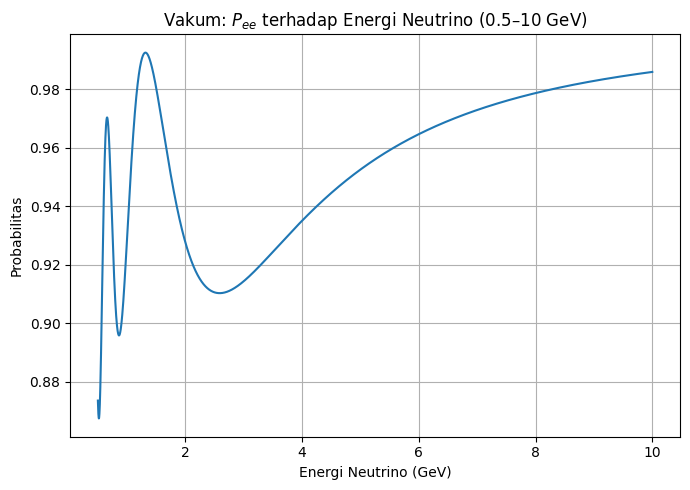

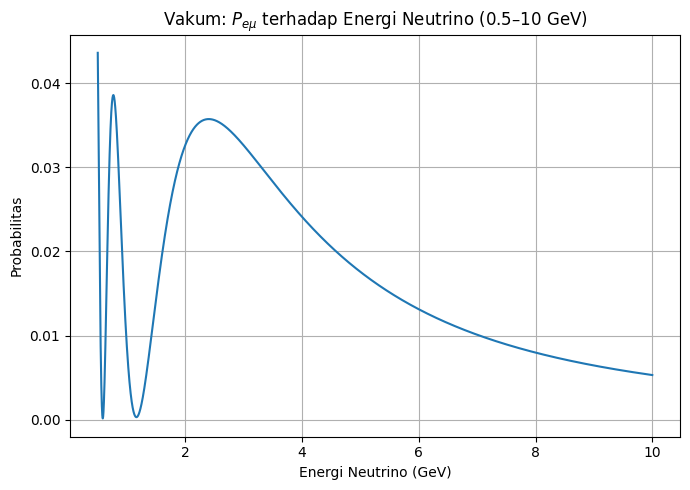

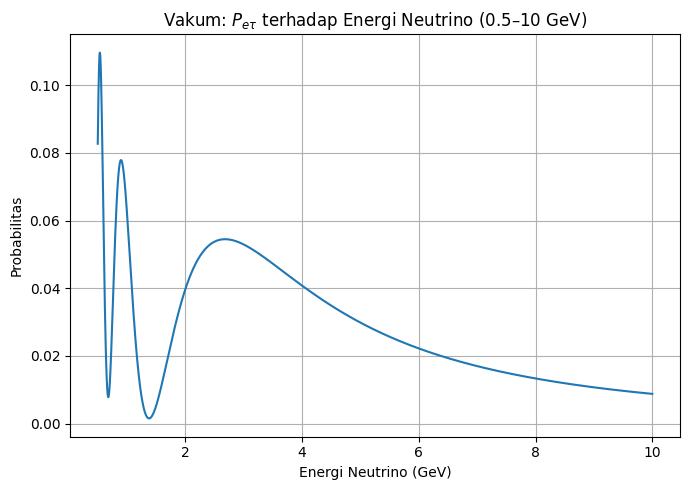

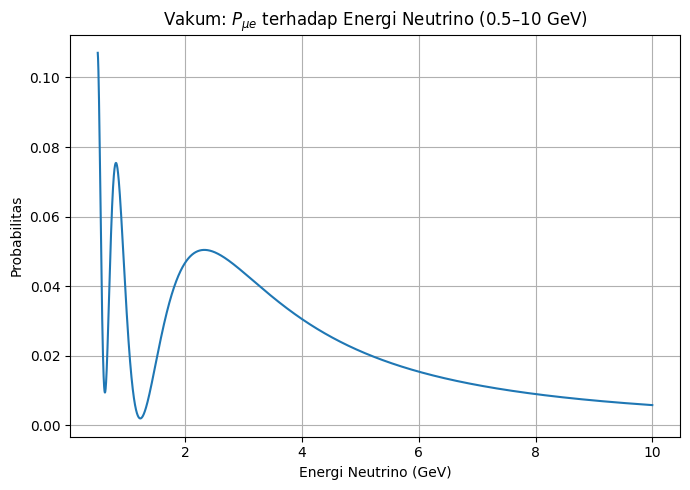

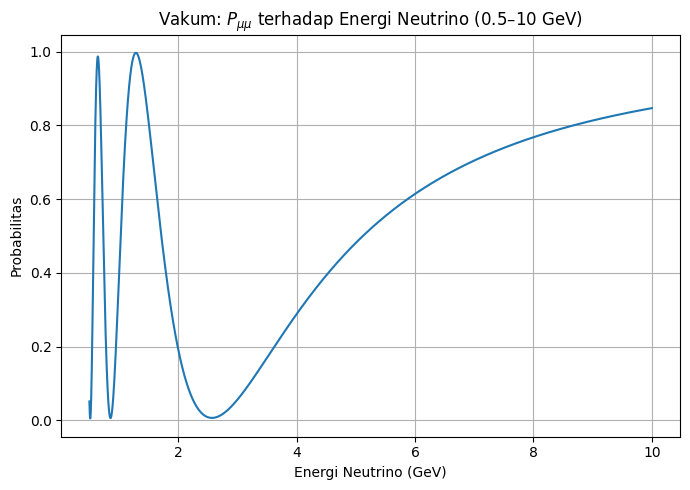

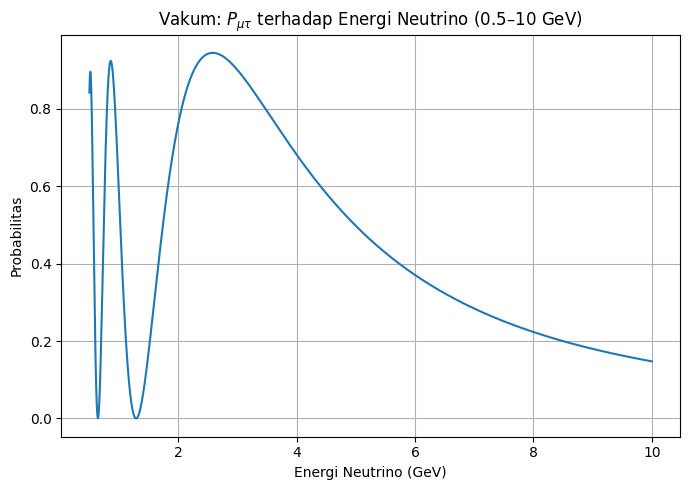

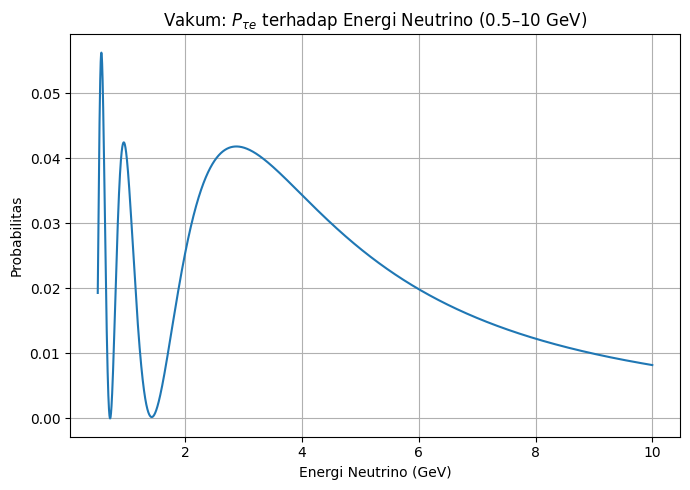

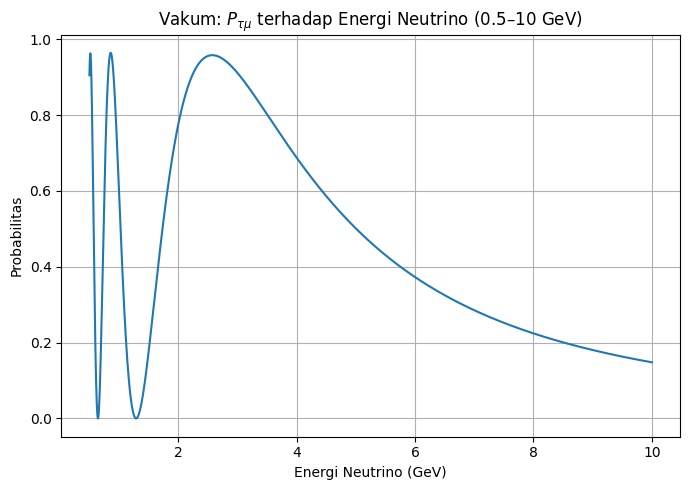

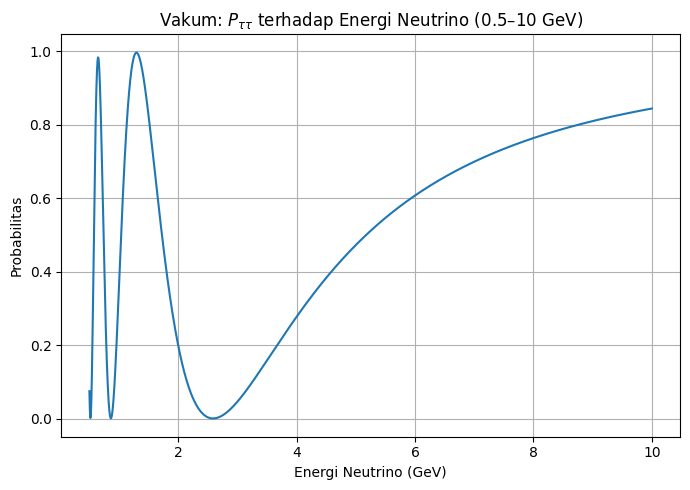

In [18]:
plot_9_probabilities_energy(
    df=df_E_full_vac,
    mode_label="Vakum",
    energy_label="0.5–10 GeV"
)

## Materi

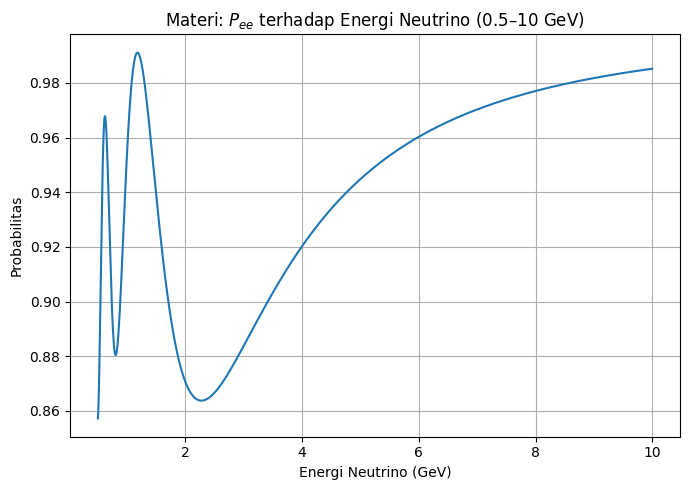

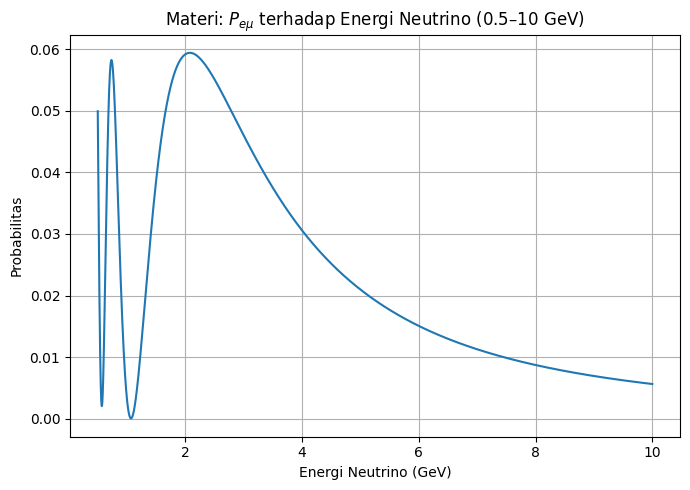

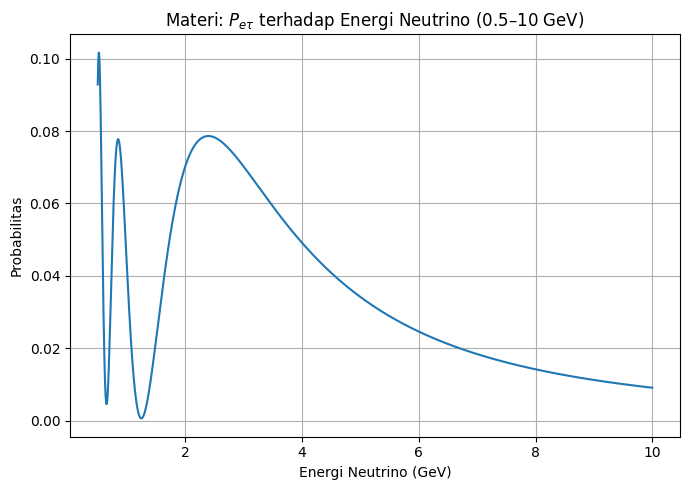

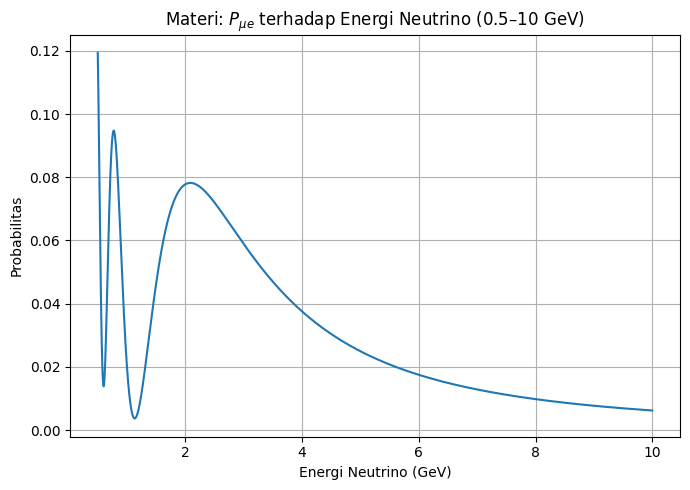

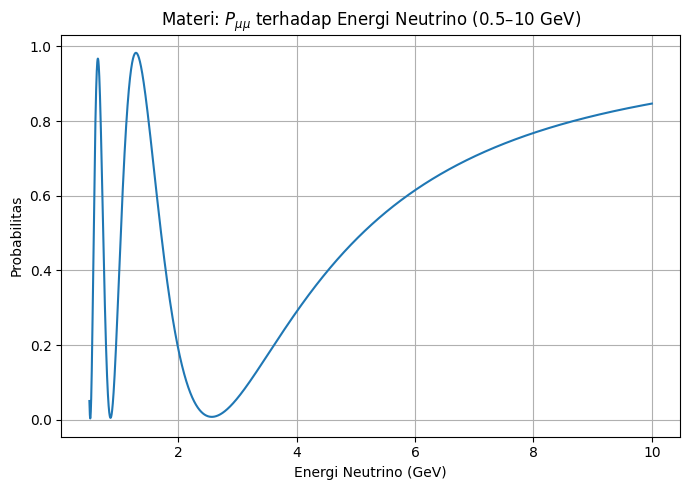

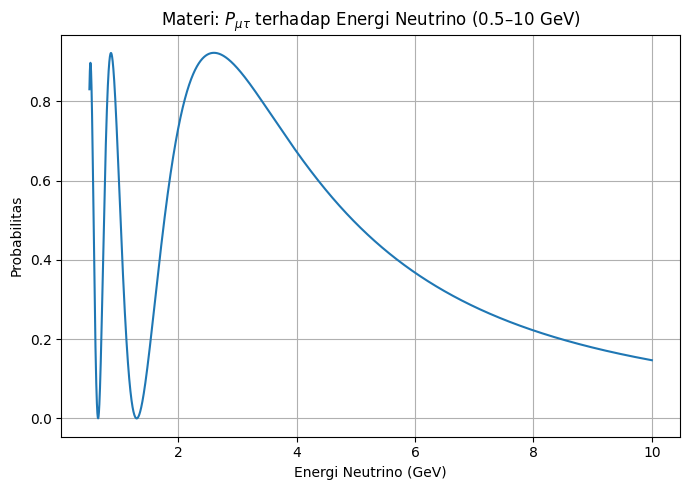

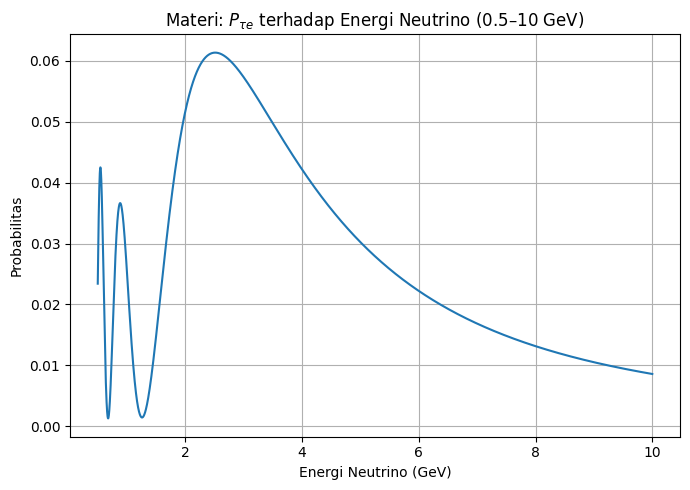

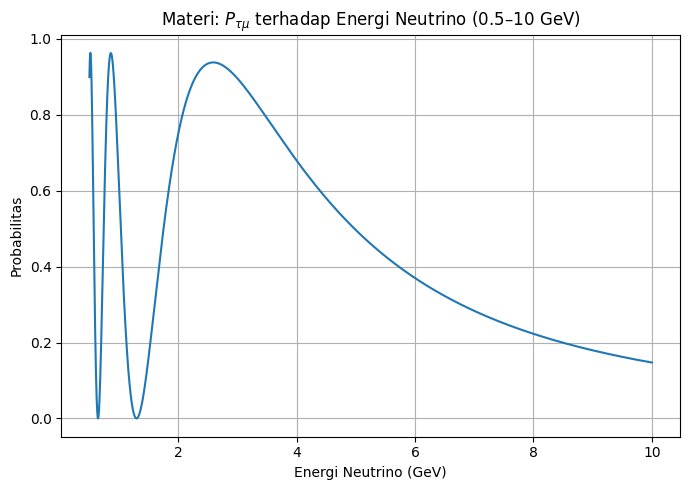

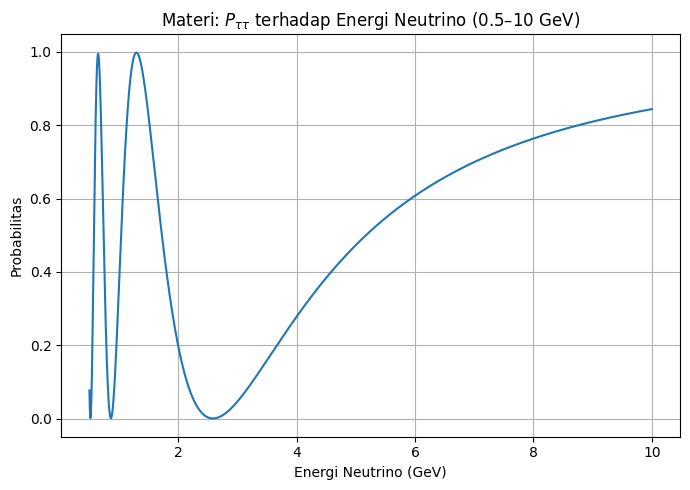

In [19]:
plot_9_probabilities_energy(
    df=df_E_full_mat,
    mode_label="Materi",
    energy_label="0.5–10 GeV"
)

## compering

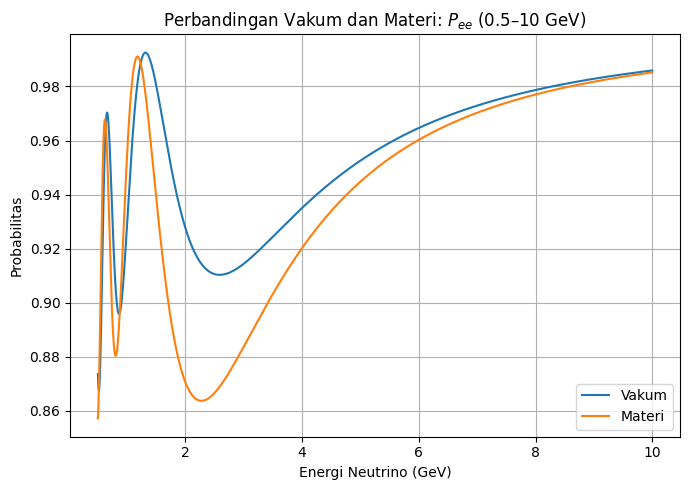

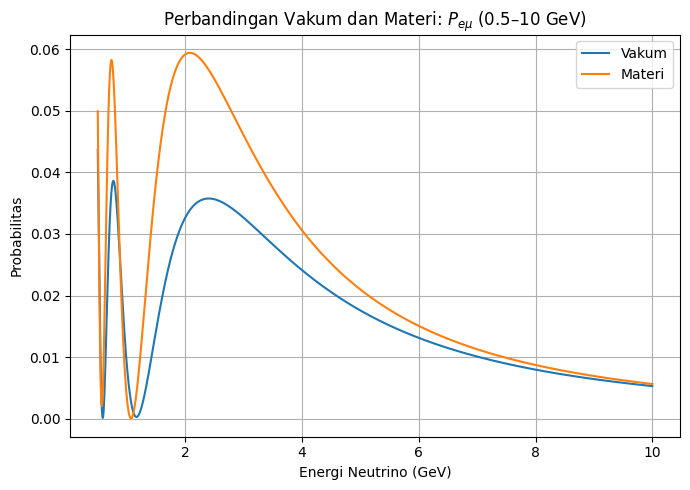

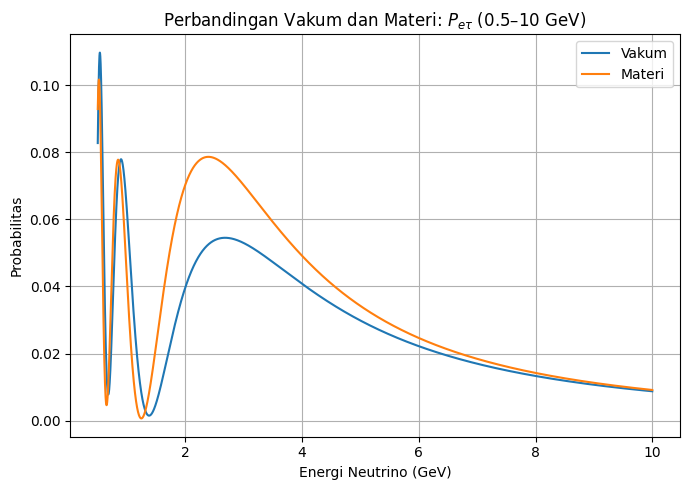

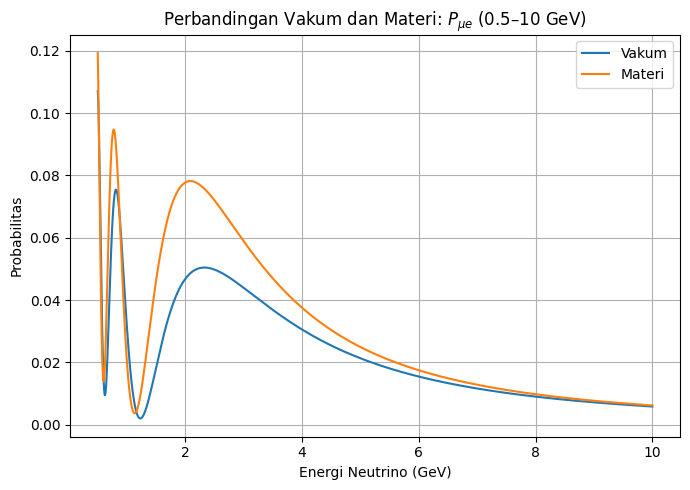

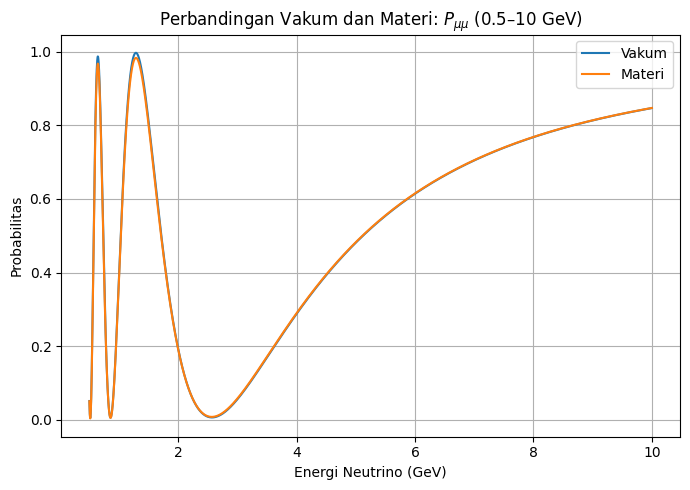

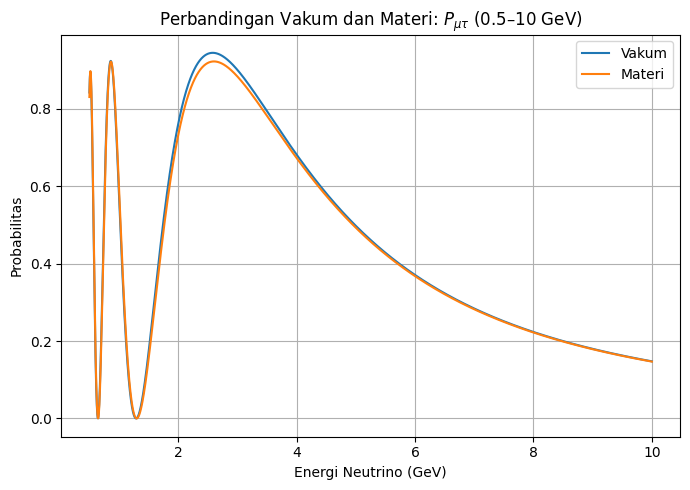

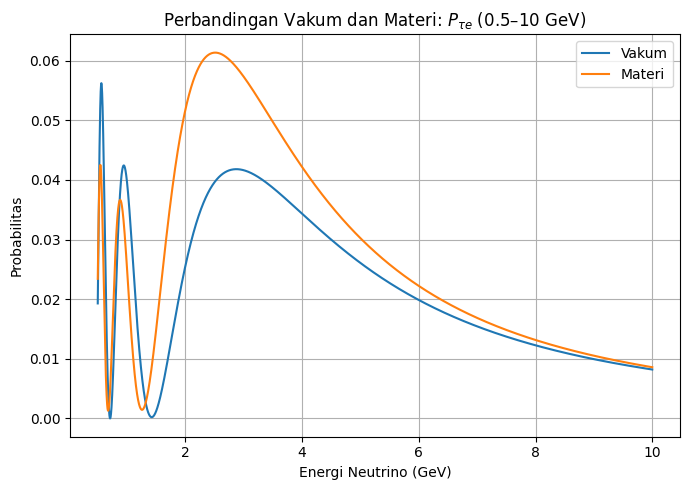

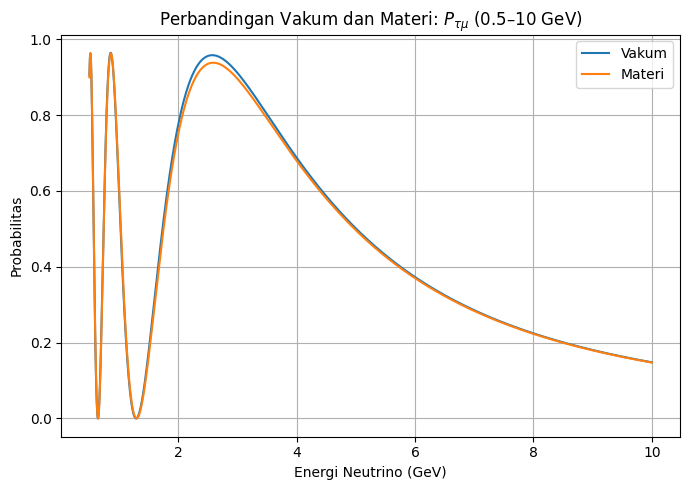

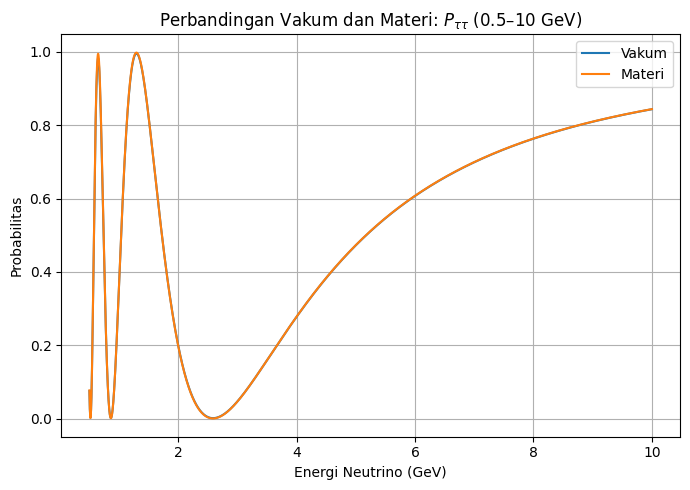

In [20]:
plot_9_compare_vacuum_matter(
    df_vac=df_E_full_vac,
    df_mat=df_E_full_mat,
    energy_label="0.5–10 GeV"
)

## Tabel puncak dan lembah

In [21]:
summary_peak_valley_full = summarize_peaks_valleys_two_conditions(
    df_vac=df_E_full_vac,
    df_mat=df_E_full_mat
)

display(summary_peak_valley_full)

,Kondisi,Probabilitas,Jenis,Urutan,E_GeV,P
0,Vakum,P_e_e,Lembah,1,0.517102,0.867538
1,Vakum,P_e_e,Puncak,1,0.657716,0.970371
2,Vakum,P_e_e,Lembah,2,0.861986,0.895893
3,Vakum,P_e_e,Puncak,2,1.315182,0.992526
4,Vakum,P_e_e,Lembah,3,2.586409,0.910343
...,...,...,...,...,...,...
80,Materi,P_tau_tau,Lembah,1,0.518052,0.001508
81,Materi,P_tau_tau,Puncak,1,0.647265,0.994925
82,Materi,P_tau_tau,Lembah,2,0.862936,0.001100
83,Materi,P_tau_tau,Puncak,2,1.294279,0.998052


In [22]:
print(summary_peak_valley_full.columns.tolist())

['Kondisi', 'Probabilitas', 'Jenis', 'Urutan', 'E_GeV', 'P']


In [23]:
nama_file = "ringkasan_puncak_lembah.xlsx"

summary_peak_valley_full.to_excel(
    nama_file,
    sheet_name="Semua Data",
    index=False
)

print(f"File berhasil dibuat: {nama_file}")

File berhasil dibuat: ringkasan_puncak_lembah.xlsx


In [24]:
#from google.colab import files

#files.download(nama_file)

In [25]:
import pandas as pd

# 1. Baca data dari file Excel
df = pd.read_excel('ringkasan_puncak_lembah.xlsx', sheet_name='Semua Data')

# 2. Pisahkan data Vakum dan Materi
vakum = df[df['Kondisi'] == 'Vakum']
materi = df[df['Kondisi'] == 'Materi']

# 3. Gabungkan berdasarkan Kanal, Jenis (Puncak/Lembah), dan Urutan
merged = pd.merge(vakum, materi, on=['Probabilitas', 'Jenis', 'Urutan'], suffixes=('_vakum', '_materi'))

# 4. Hitung selisih absolut energi dan probabilitas
merged['delta_E'] = (merged['E_GeV_vakum'] - merged['E_GeV_materi']).abs()
merged['delta_P'] = (merged['P_vakum'] - merged['P_materi']).abs()

# 5. Cari nilai pergeseran maksimum untuk setiap kanal
tabel_ringkasan = merged.groupby('Probabilitas').agg(
    delta_E_maks=('delta_E', 'max'),
    delta_P_maks=('delta_P', 'max')
).reset_index()

# 6. Format tampilan numerik
tabel_ringkasan['delta_E_maks'] = tabel_ringkasan['delta_E_maks'].round(3)
tabel_ringkasan['delta_P_maks'] = tabel_ringkasan['delta_P_maks'].round(4)

print(tabel_ringkasan)

  Probabilitas  delta_E_maks  delta_P_maks
0        P_e_e         1.414        0.0321
1       P_e_mu         0.322        0.0237
2      P_e_tau         0.286        0.0241
3       P_mu_e         0.239        0.0278
4      P_mu_mu         0.004        0.0194
5     P_mu_tau         0.021        0.0222
6      P_tau_e         0.362        0.0195
7     P_tau_mu         0.016        0.0199
8    P_tau_tau         0.002        0.0123


## Energi Rendah

In [26]:
E_low = np.linspace(0.5, 3.0, 5000)

df_E_low_vac = probabilities_vs_energy(E_low, mode="vacuum")
df_E_low_mat = probabilities_vs_energy(E_low, mode="matter")

### Vakum

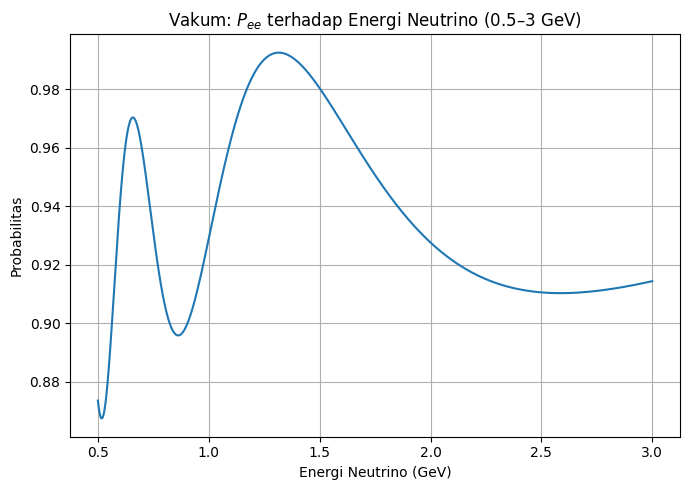

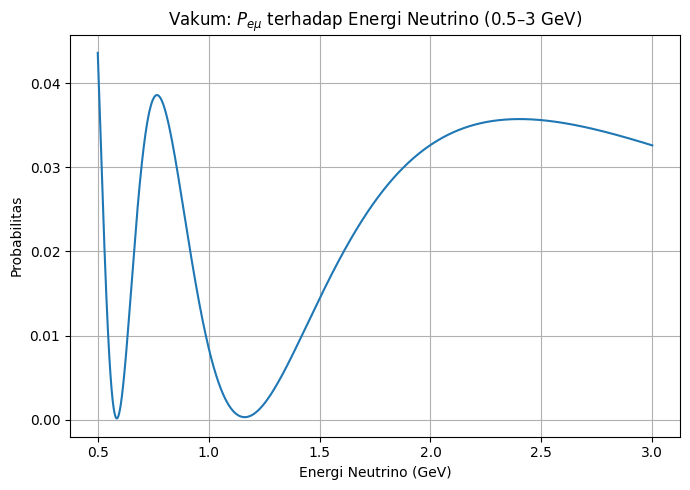

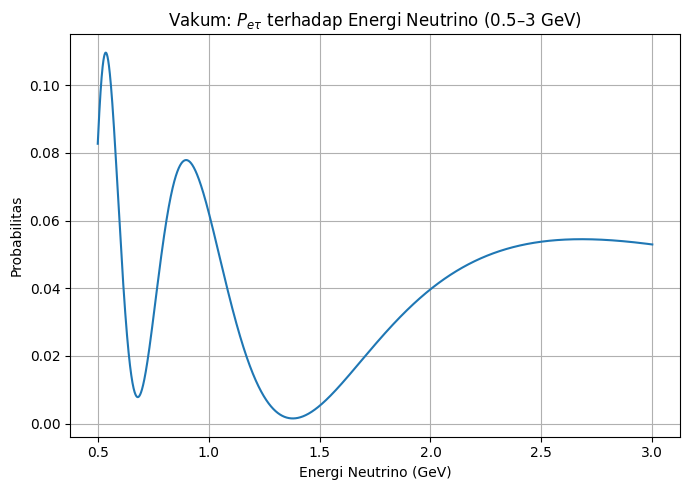

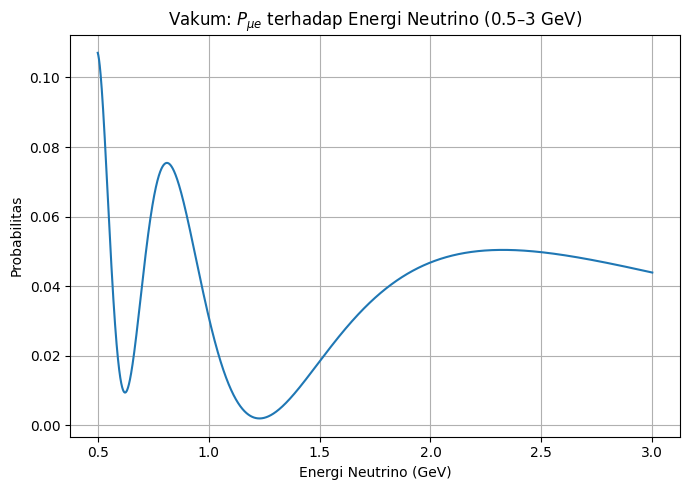

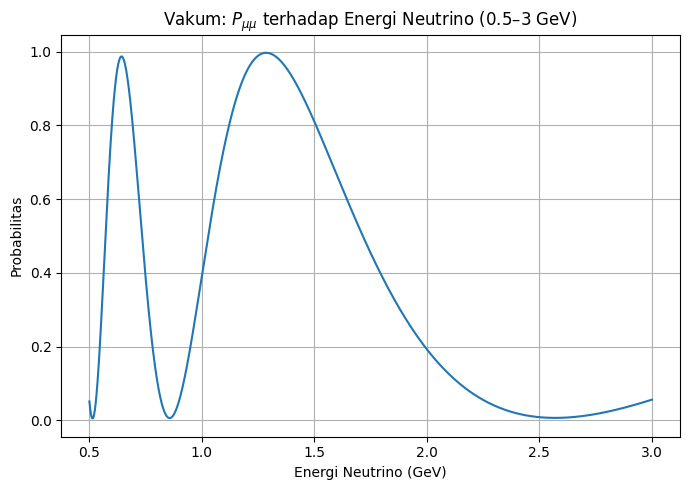

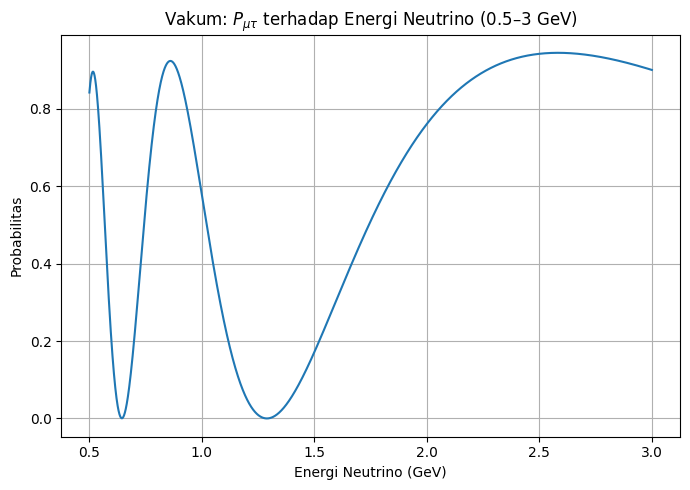

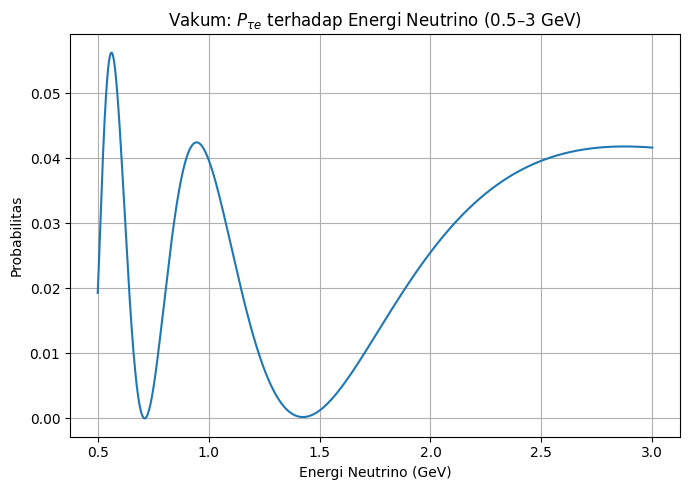

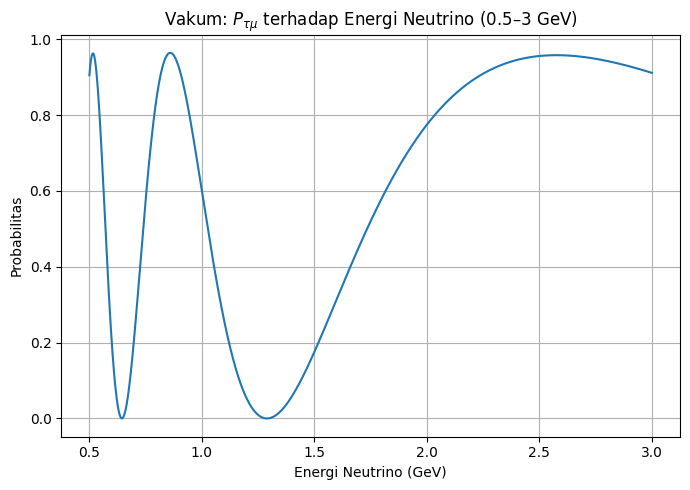

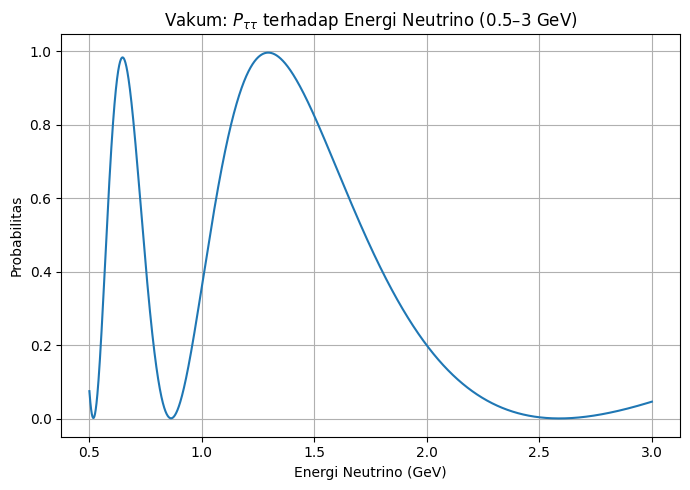

In [27]:
plot_9_probabilities_energy(
    df=df_E_low_vac,
    mode_label="Vakum",
    energy_label="0.5–3 GeV"
)

### Materi

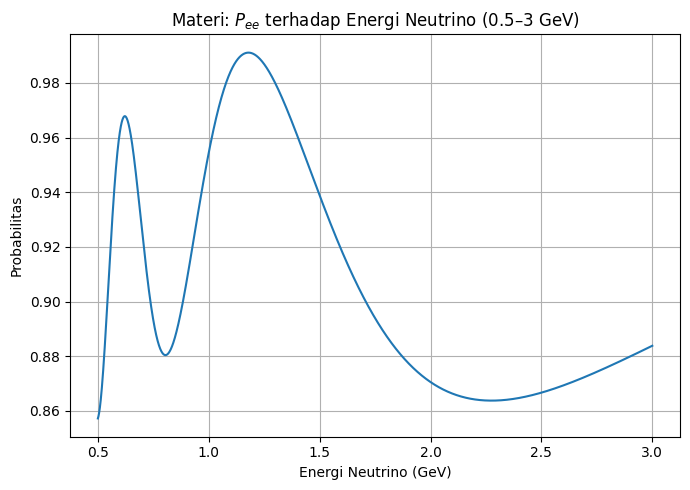

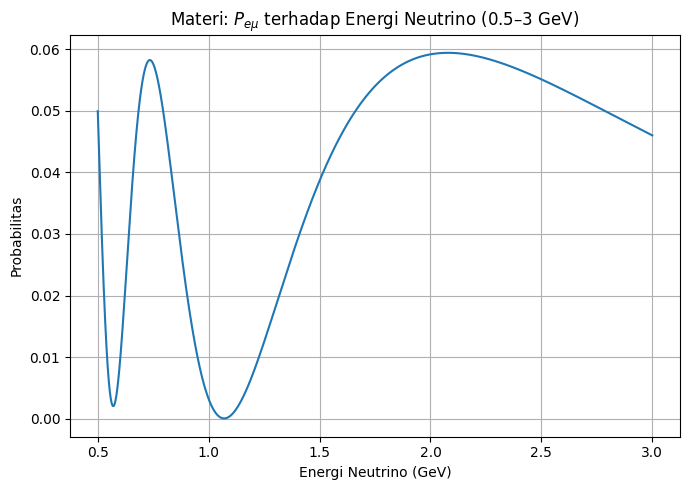

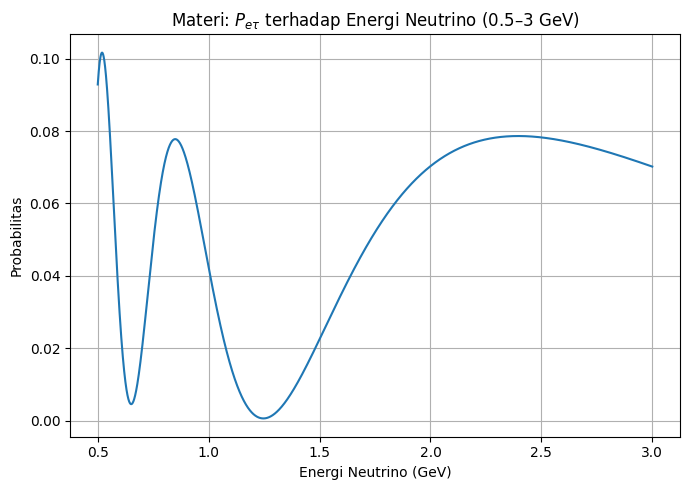

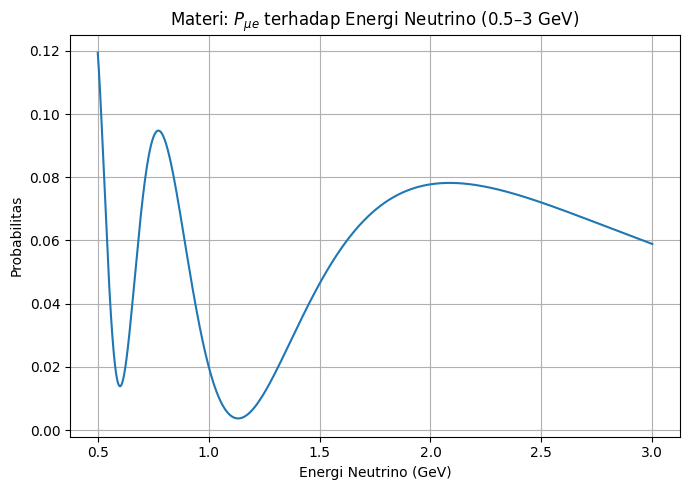

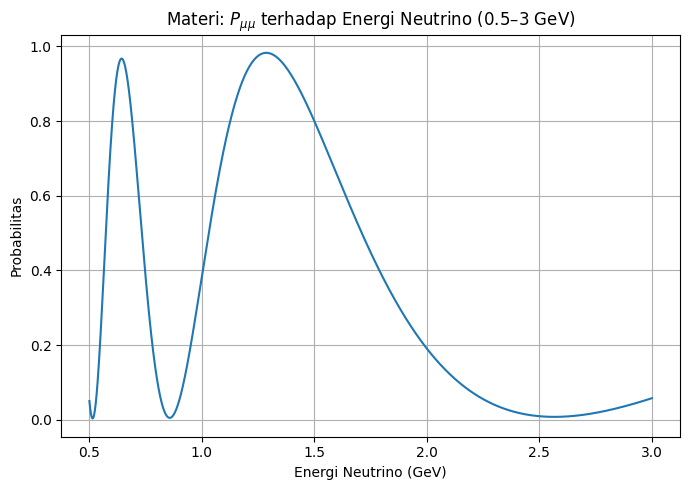

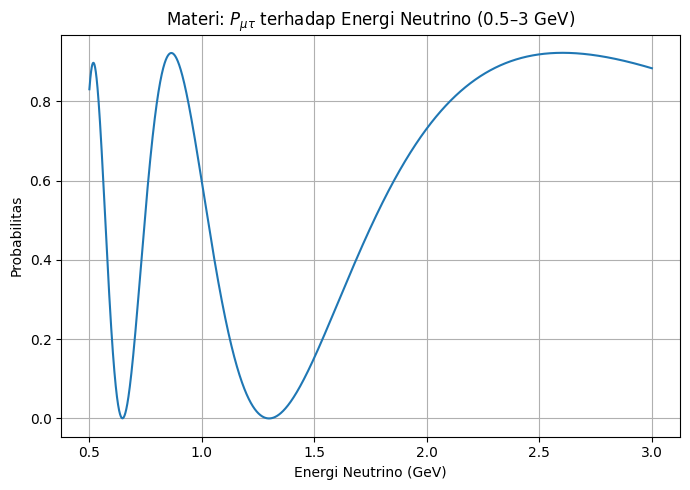

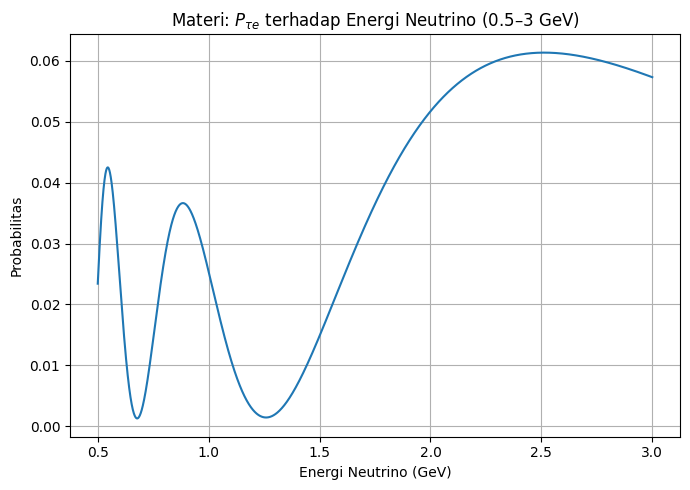

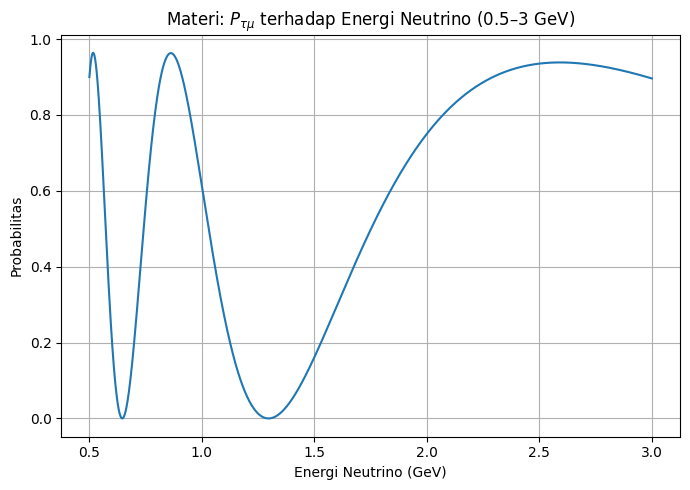

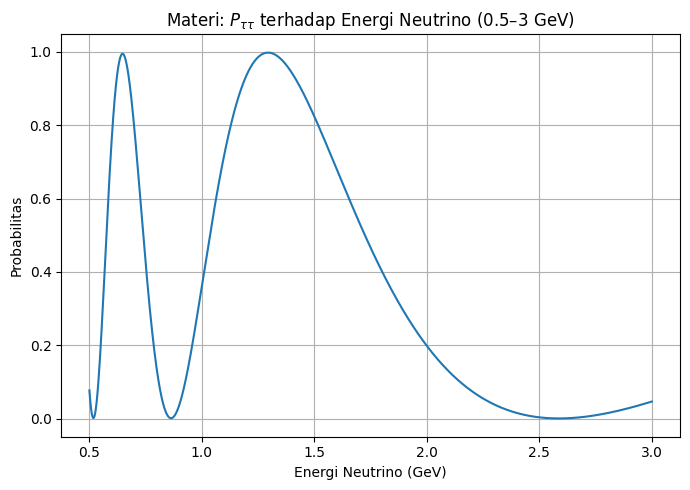

In [28]:
plot_9_probabilities_energy(
    df=df_E_low_mat,
    mode_label="Materi",
    energy_label="0.5–3 GeV"
)

### compering

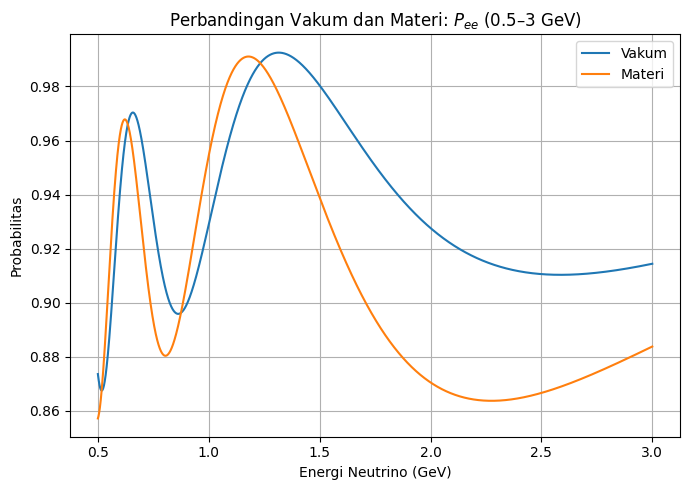

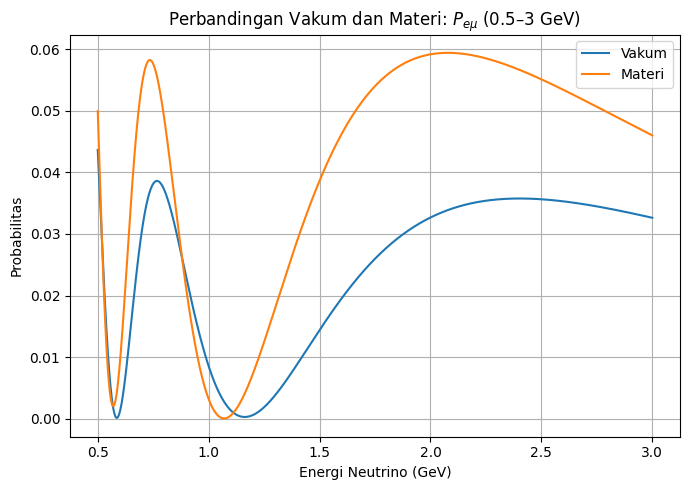

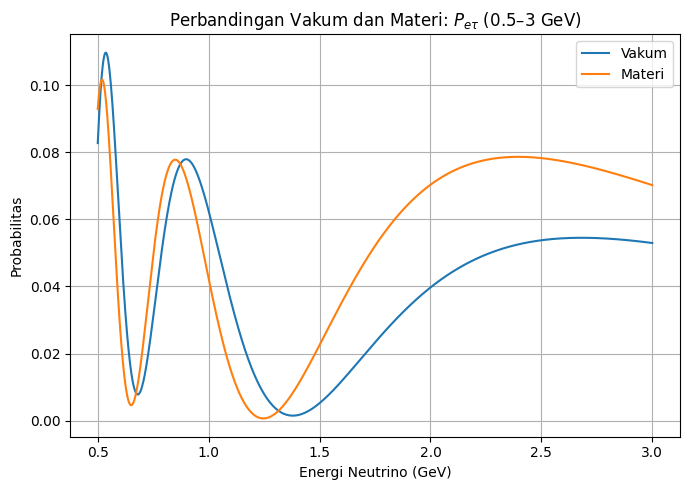

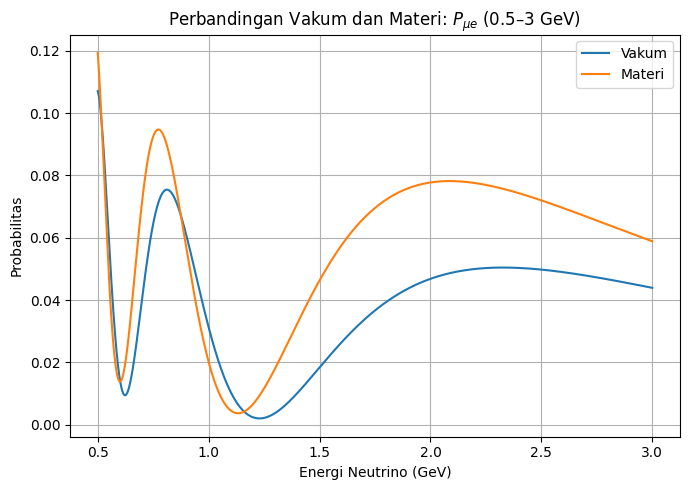

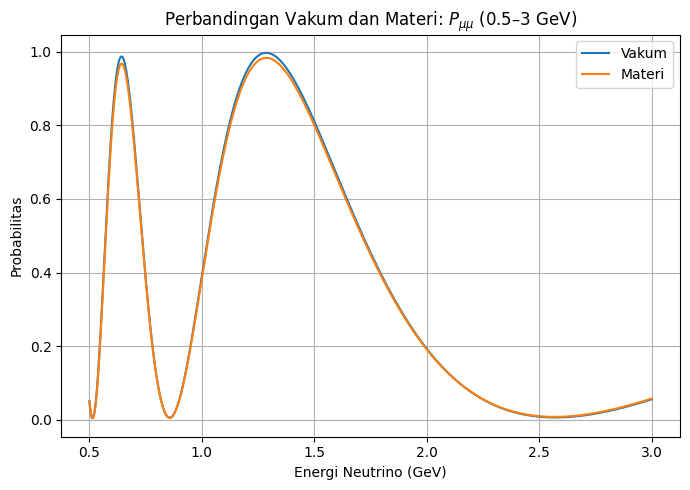

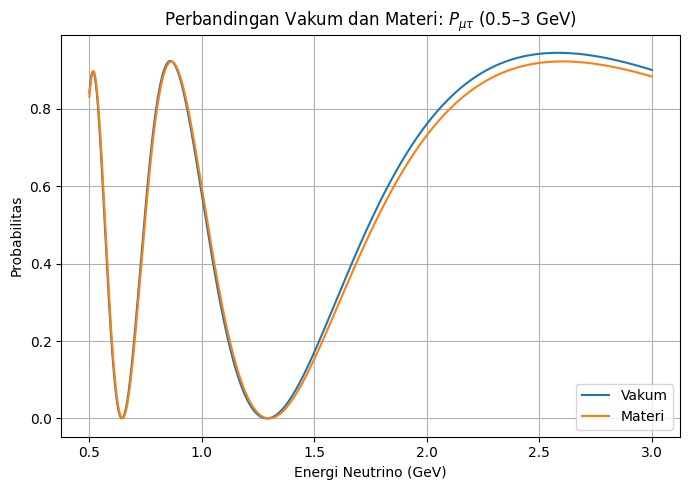

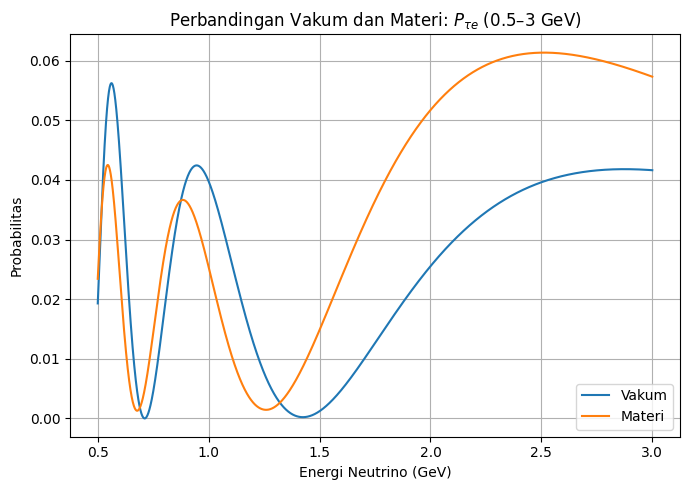

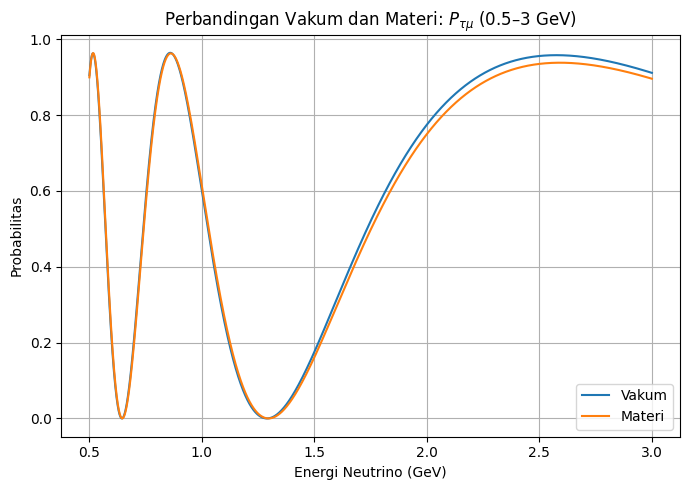

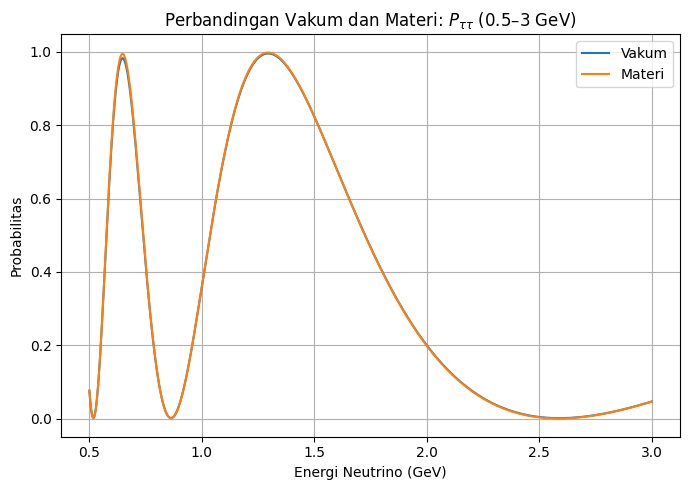

In [29]:
plot_9_compare_vacuum_matter(
    df_vac=df_E_low_vac,
    df_mat=df_E_low_mat,
    energy_label="0.5–3 GeV"
)

## Baseline ($L$)

In [30]:
L_values = [295, 810, 1300]

baseline_full_vac = probabilities_vs_energy_for_baseline(
    E_values_GeV=E_full,
    L_values=L_values,
    mode="vacuum"
)

baseline_full_mat = probabilities_vs_energy_for_baseline(
    E_values_GeV=E_full,
    L_values=L_values,
    mode="matter",
    Vcc_value=Vcc
)

### Vakum

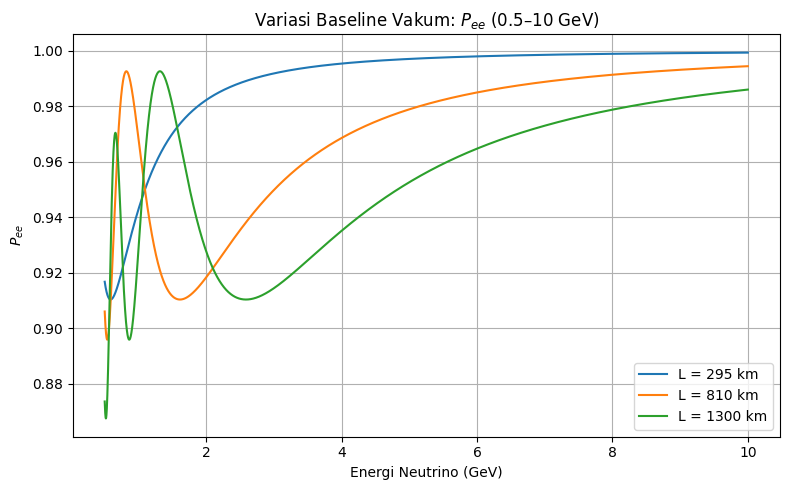

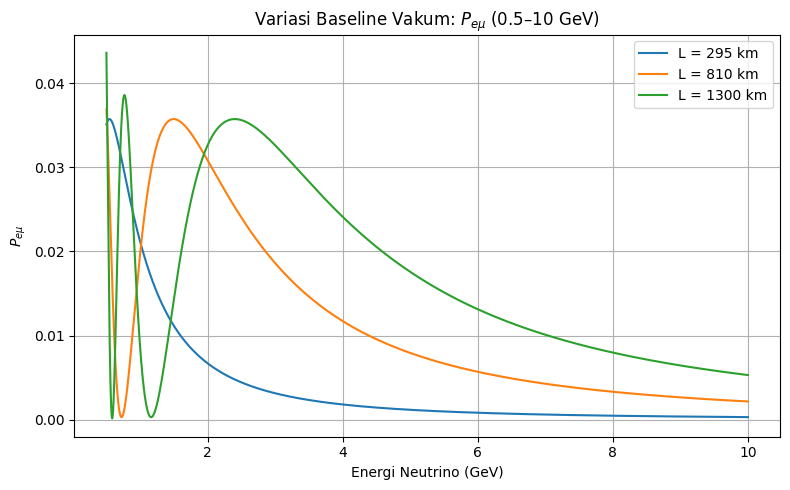

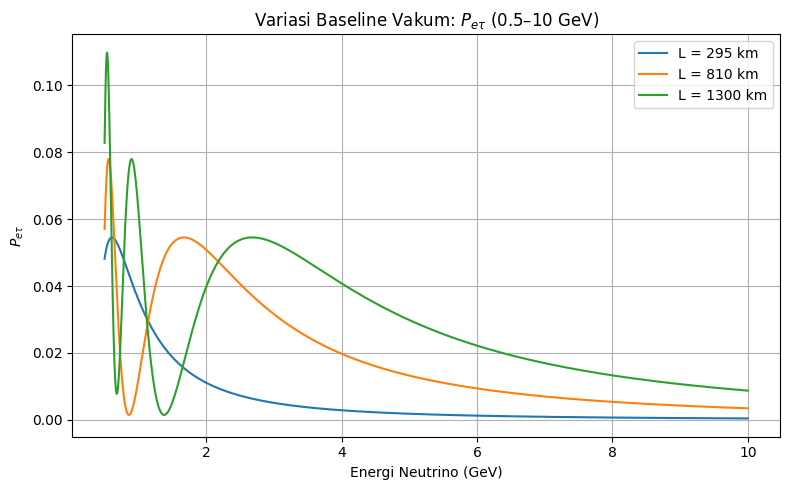

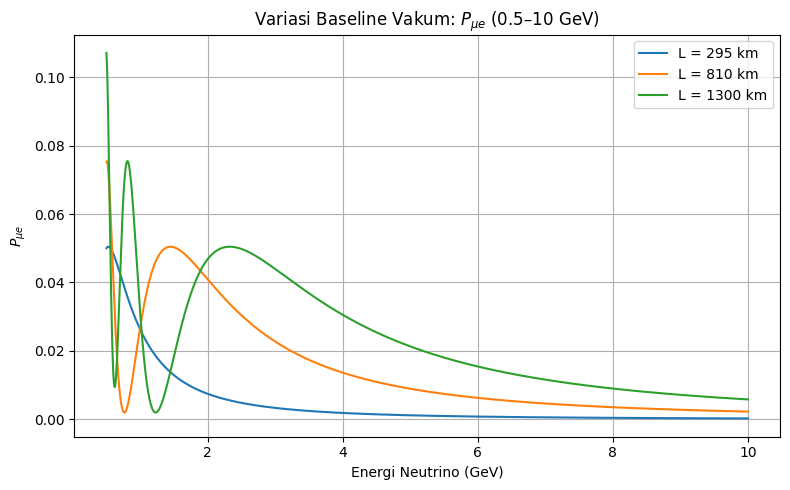

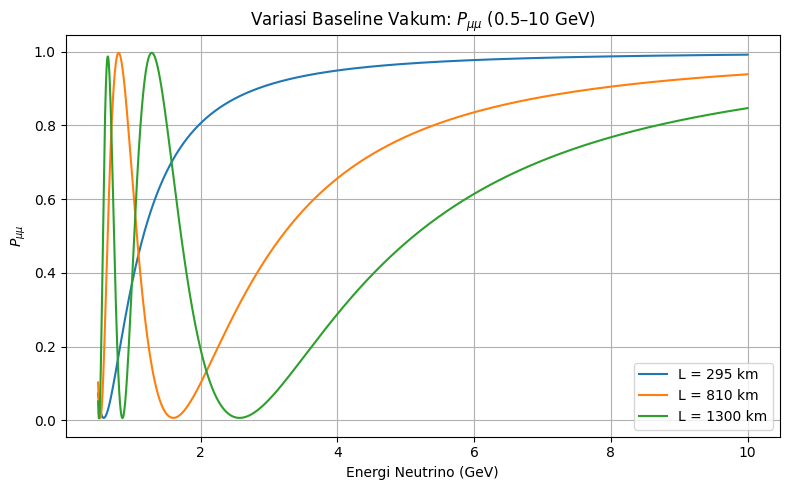

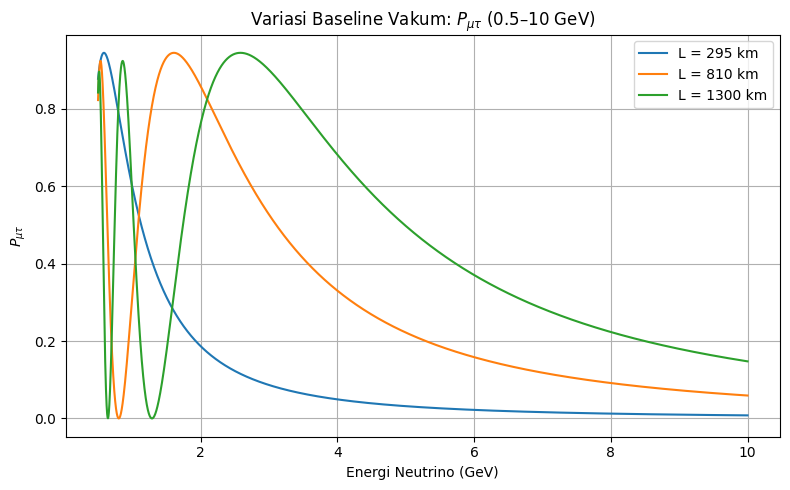

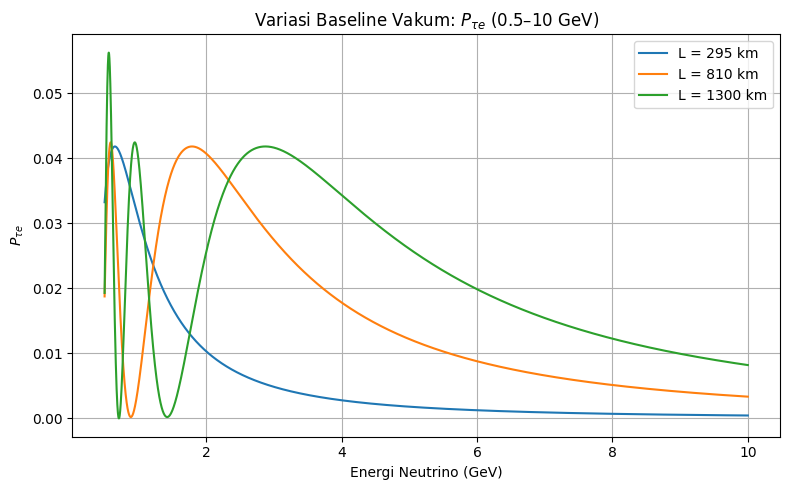

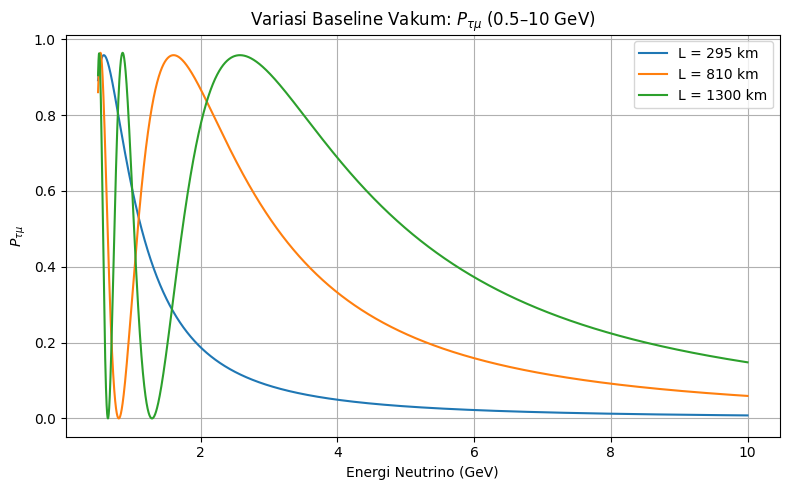

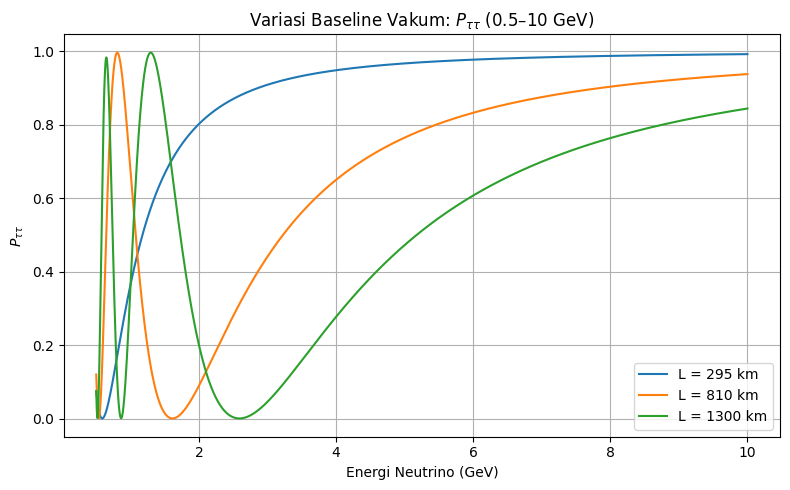

In [31]:
plot_9_baseline_variation(
    baseline_results=baseline_full_vac,
    mode_label="Vakum",
    energy_label="0.5–10 GeV"
)

### Materi

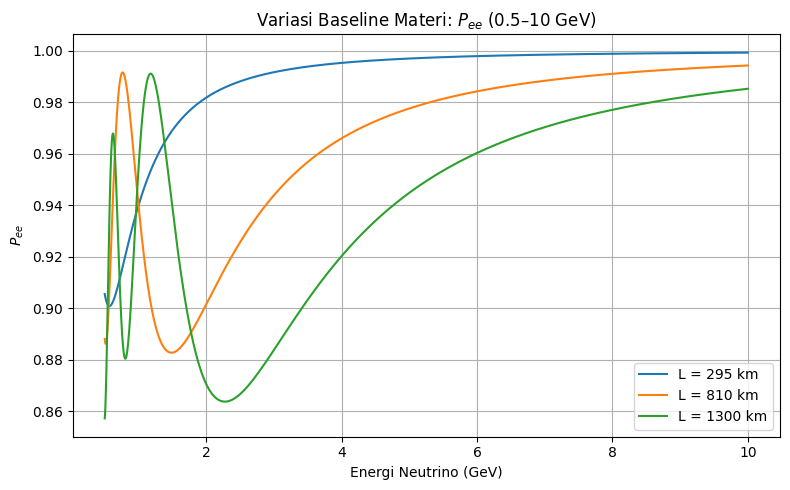

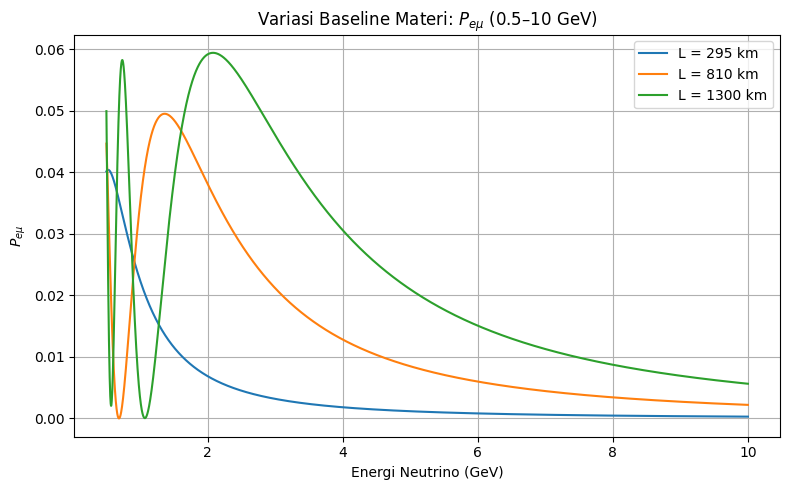

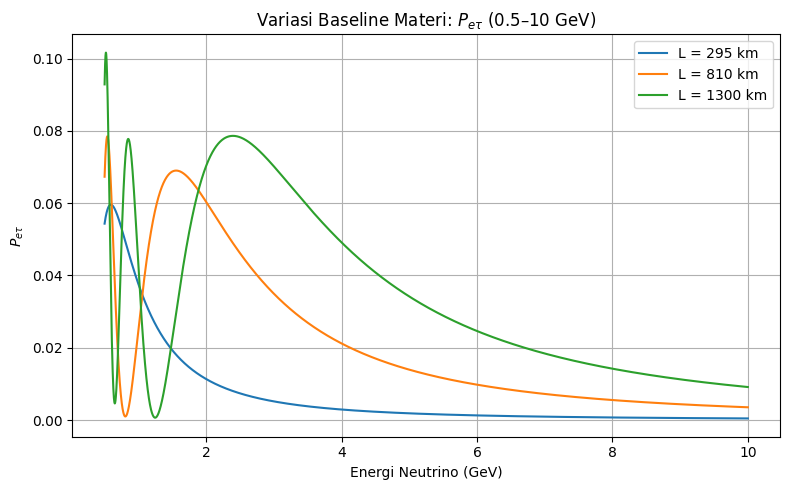

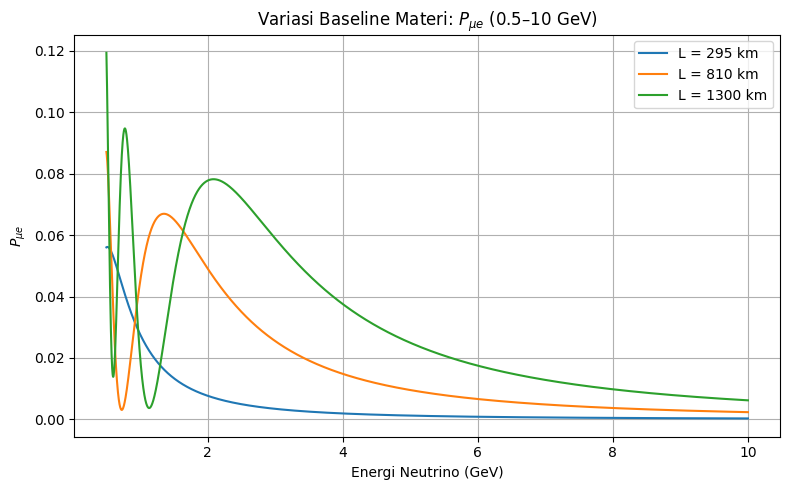

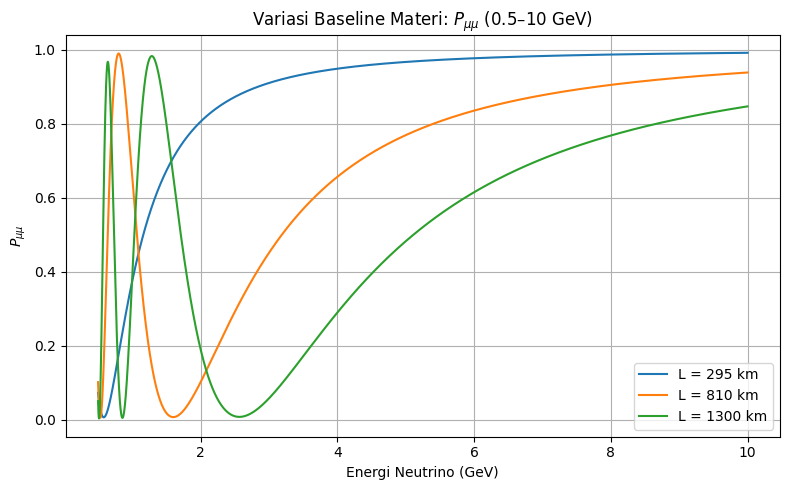

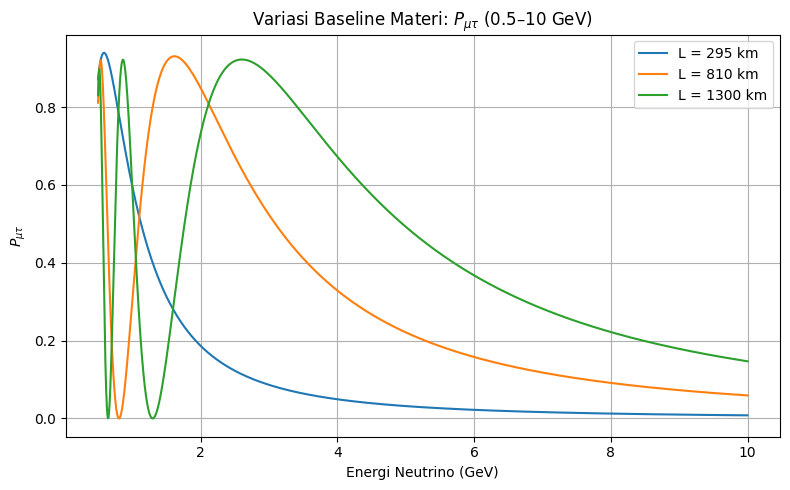

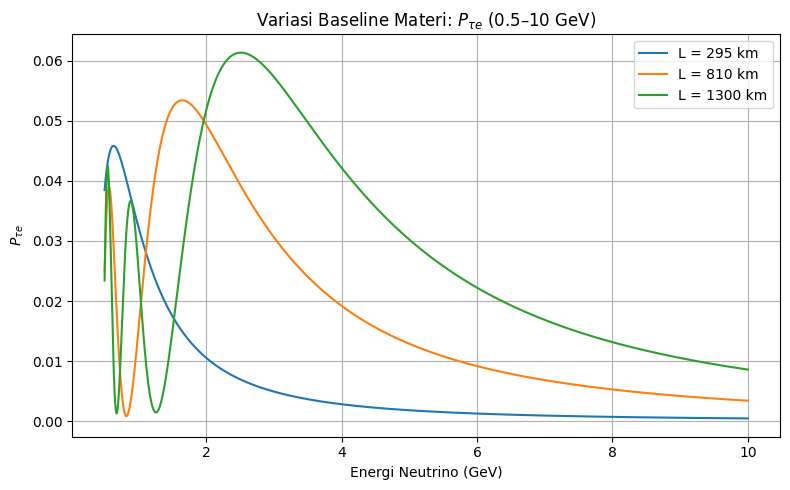

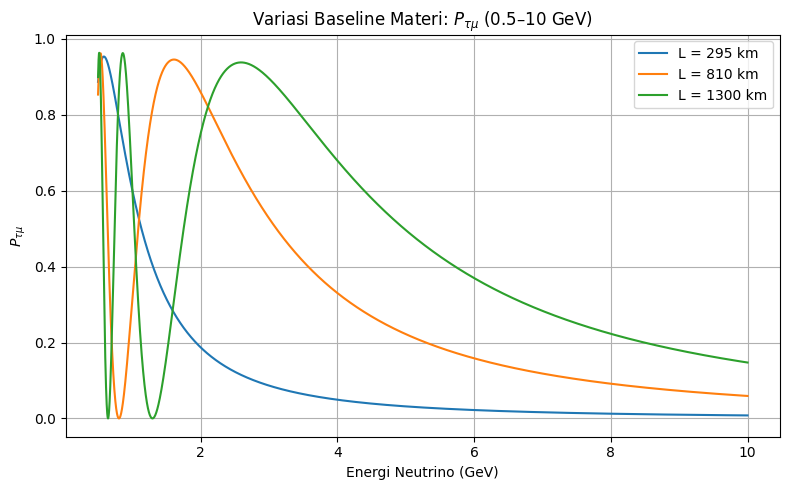

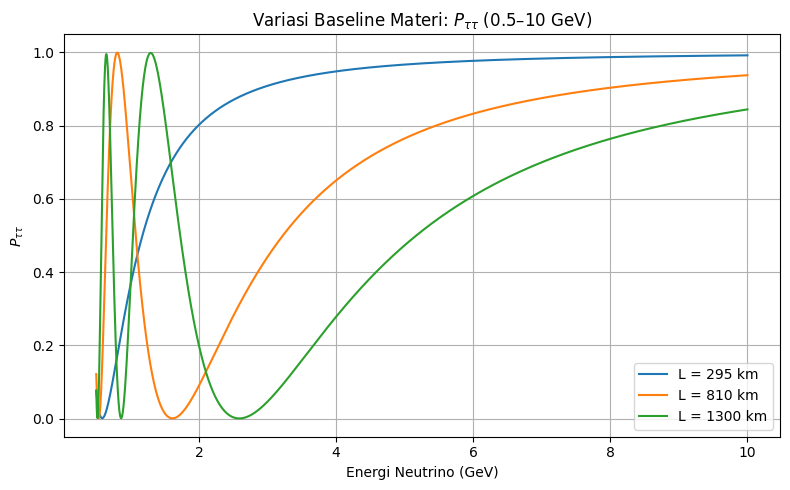

In [32]:
plot_9_baseline_variation(
    baseline_results=baseline_full_mat,
    mode_label="Materi",
    energy_label="0.5–10 GeV"
)

## Tabel - Baseline

In [33]:
summary_peak_valley_baseline_vac = summarize_peaks_valleys_baseline(
    baseline_results=baseline_full_vac,
    mode_label="Vakum"
)

summary_peak_valley_baseline_mat = summarize_peaks_valleys_baseline(
    baseline_results=baseline_full_mat,
    mode_label="Materi"
)

summary_peak_valley_baseline = pd.concat(
    [summary_peak_valley_baseline_vac, summary_peak_valley_baseline_mat],
    ignore_index=True
)

display(summary_peak_valley_baseline)

,Kondisi,Baseline_km,Probabilitas,Jenis,Urutan,E_GeV,P
0,Vakum,295,P_e_e,Lembah,1,0.587409,0.910343
1,Vakum,295,P_e_mu,Puncak,1,0.544654,0.035755
2,Vakum,295,P_e_tau,Puncak,1,0.608311,0.054499
3,Vakum,295,P_mu_e,Puncak,1,0.527553,0.050448
4,Vakum,295,P_mu_mu,Lembah,1,0.583608,0.006459
...,...,...,...,...,...,...,...
149,Materi,1300,P_tau_tau,Lembah,1,0.518052,0.001508
150,Materi,1300,P_tau_tau,Puncak,1,0.647265,0.994925
151,Materi,1300,P_tau_tau,Lembah,2,0.862936,0.001100
152,Materi,1300,P_tau_tau,Puncak,2,1.294279,0.998052


In [34]:
print(summary_peak_valley_baseline.columns.tolist())

['Kondisi', 'Baseline_km', 'Probabilitas', 'Jenis', 'Urutan', 'E_GeV', 'P']


In [35]:
nama_file_baseline = "ringkasan_puncak_lembah_baseline.xlsx"

summary_peak_valley_baseline.to_excel(
    nama_file_baseline,
    sheet_name="Semua Data",
    index=False
)

print(f"File berhasil dibuat: {nama_file_baseline}")

File berhasil dibuat: ringkasan_puncak_lembah_baseline.xlsx


In [36]:
from google.colab import files

files.download(nama_file_baseline)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Baseline - Energi Rendah

In [37]:
baseline_low_vac = probabilities_vs_energy_for_baseline(
    E_values_GeV=E_low,
    L_values=L_values,
    mode="vacuum"
)

baseline_low_mat = probabilities_vs_energy_for_baseline(
    E_values_GeV=E_low,
    L_values=L_values,
    mode="matter",
    Vcc_value=Vcc
)

### Vakum

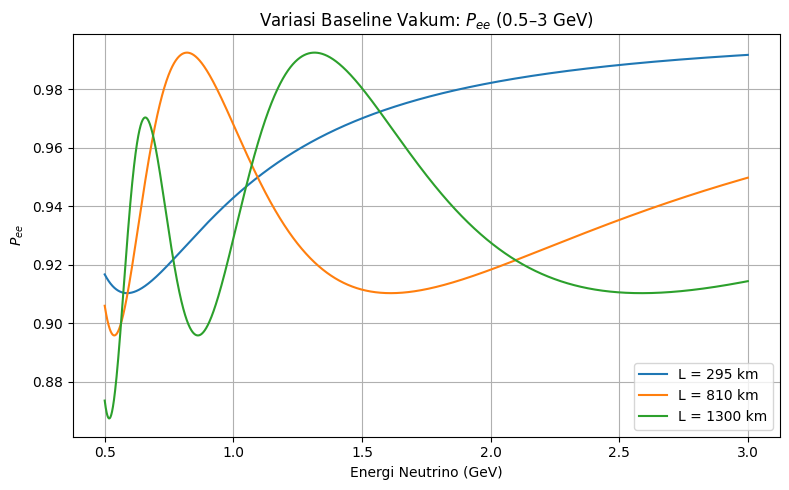

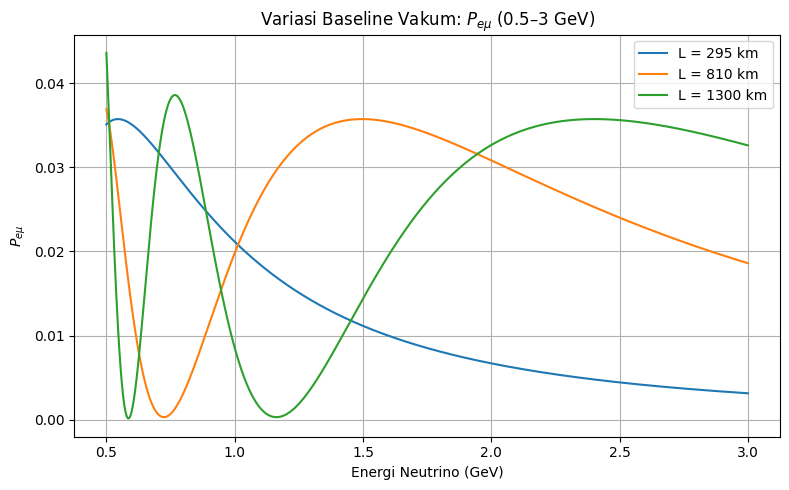

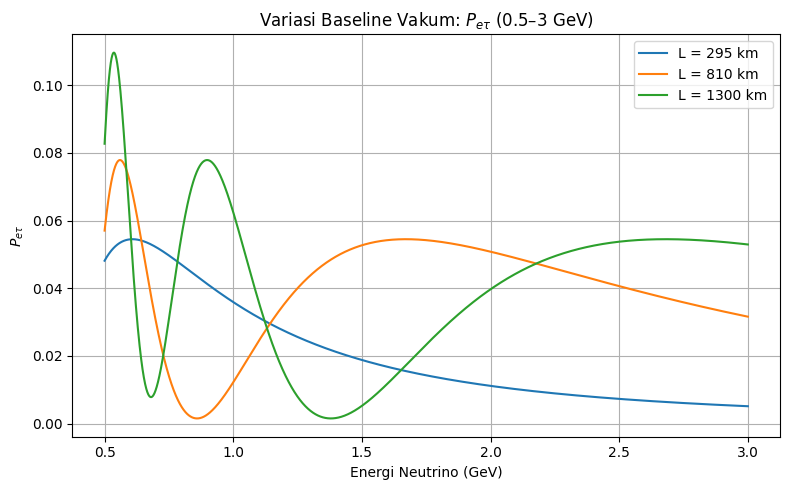

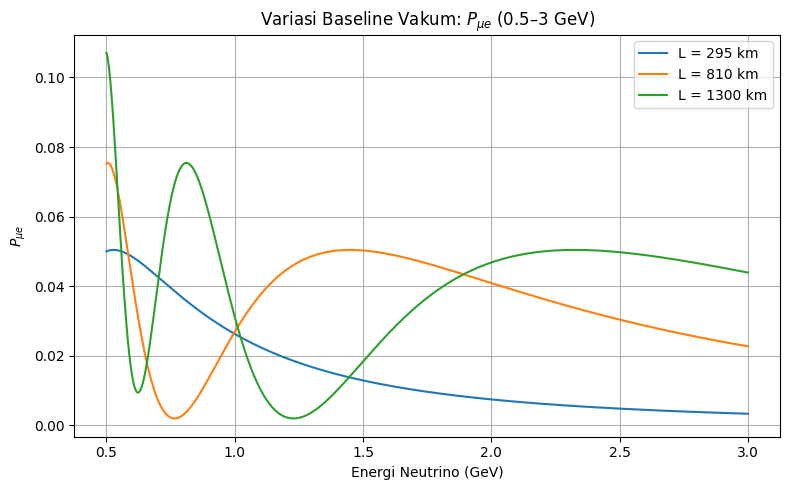

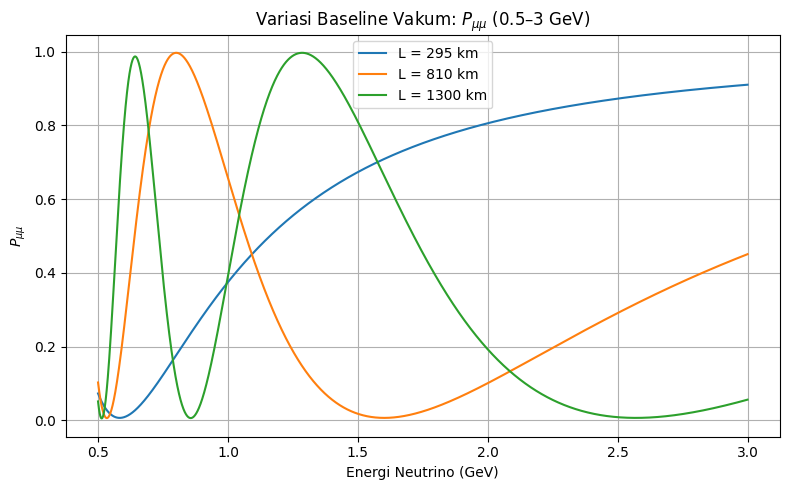

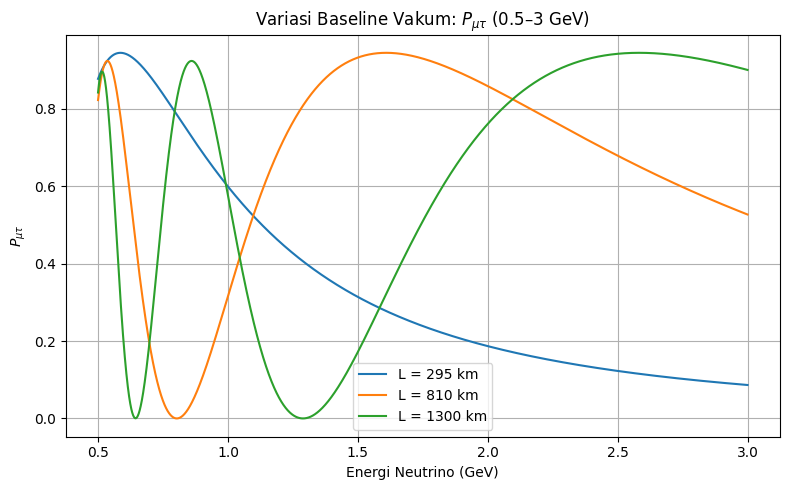

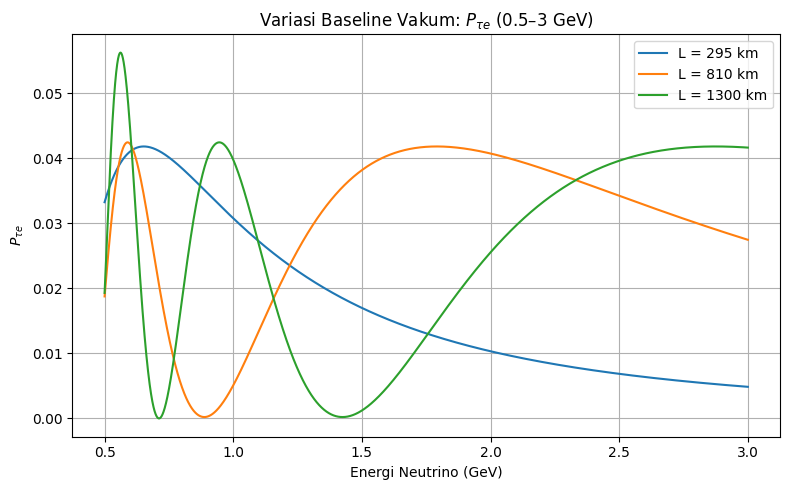

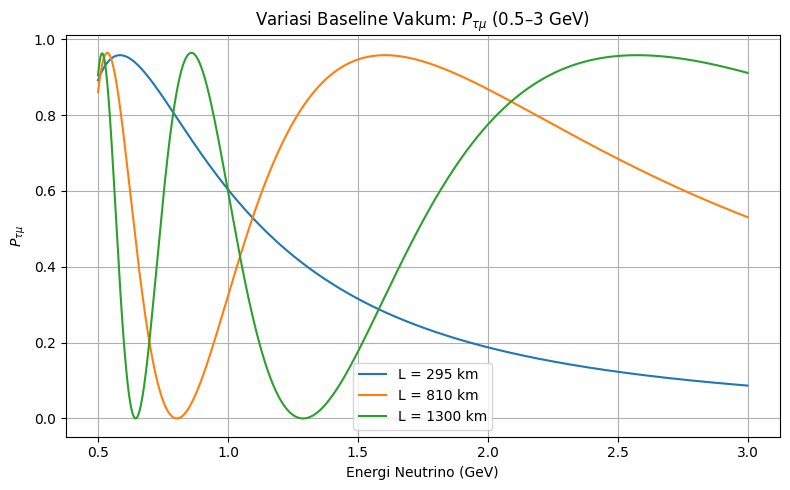

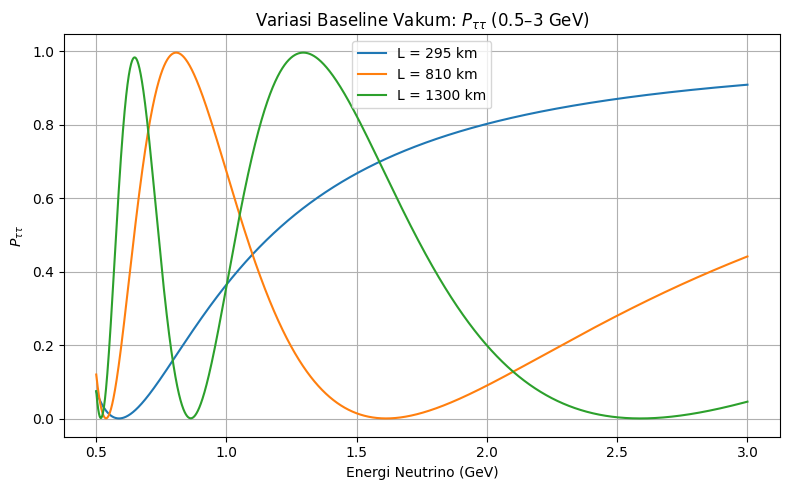

In [38]:
plot_9_baseline_variation(
    baseline_results=baseline_low_vac,
    mode_label="Vakum",
    energy_label="0.5–3 GeV"
)

### Materi

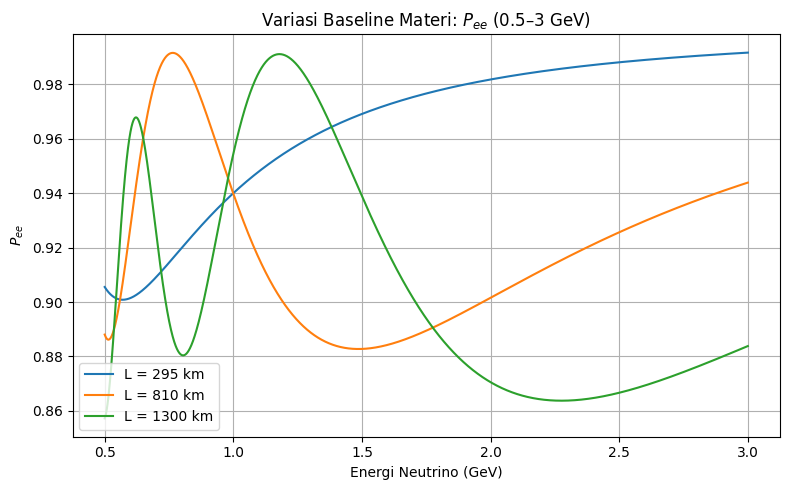

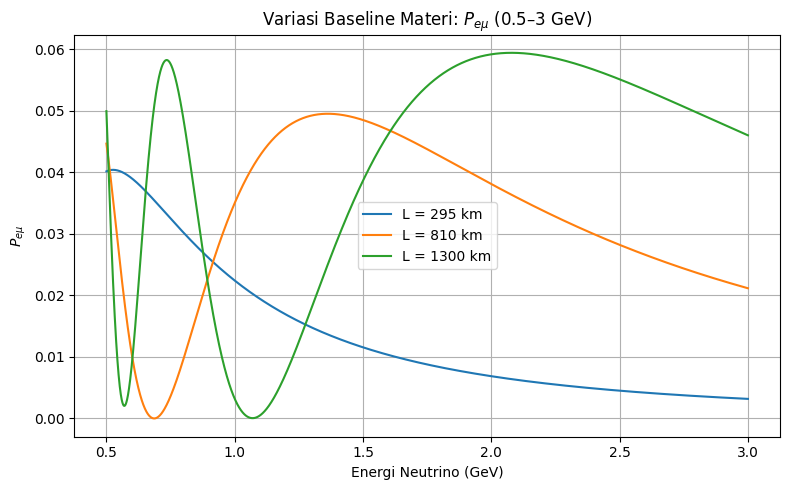

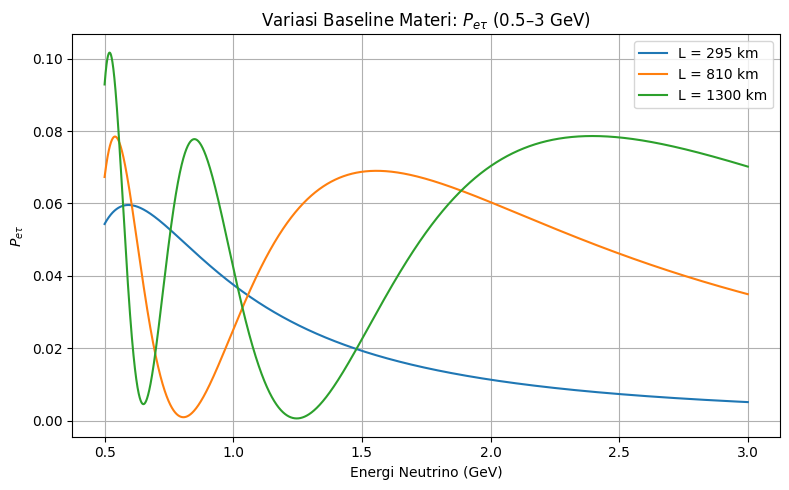

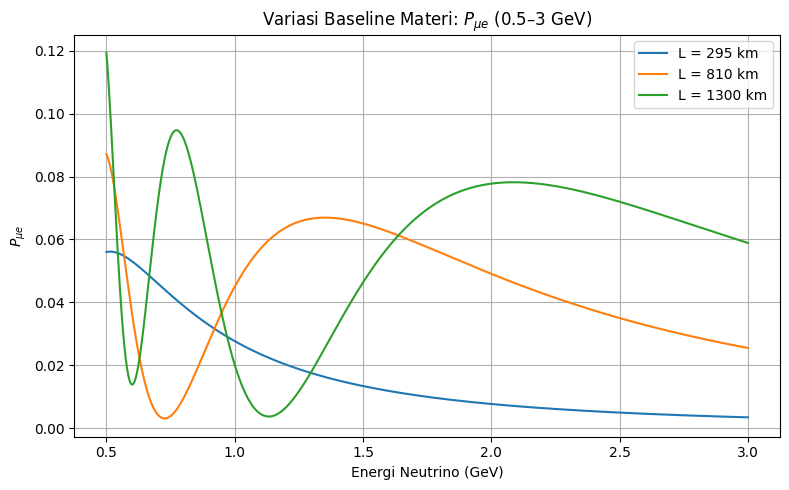

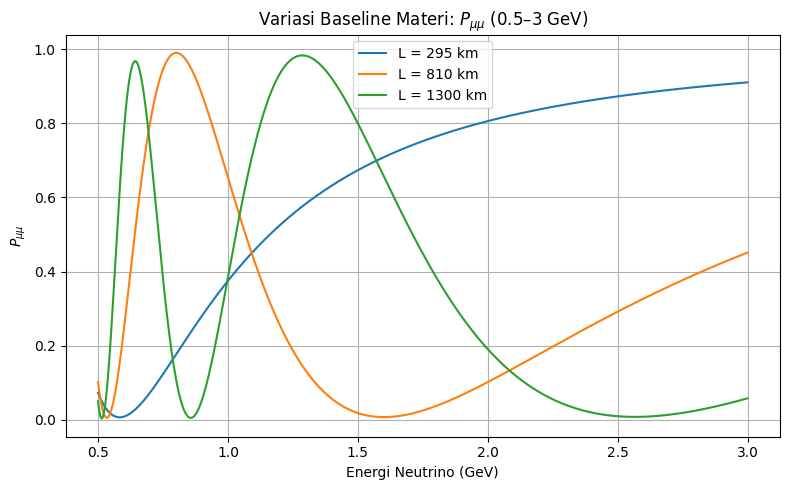

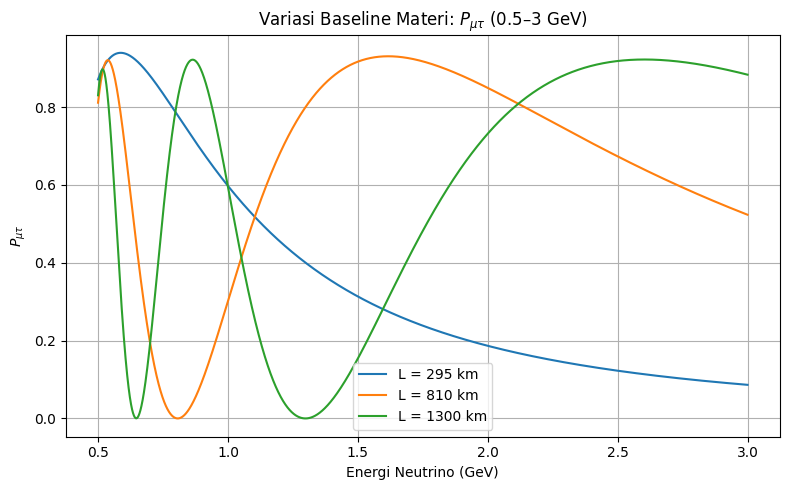

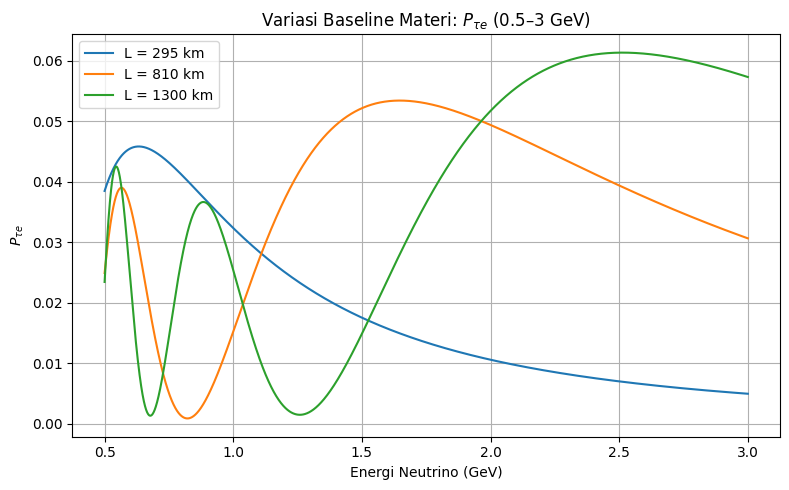

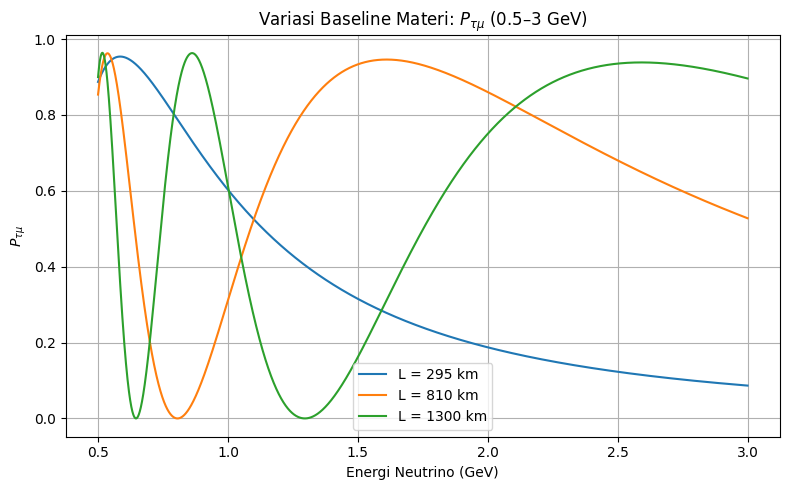

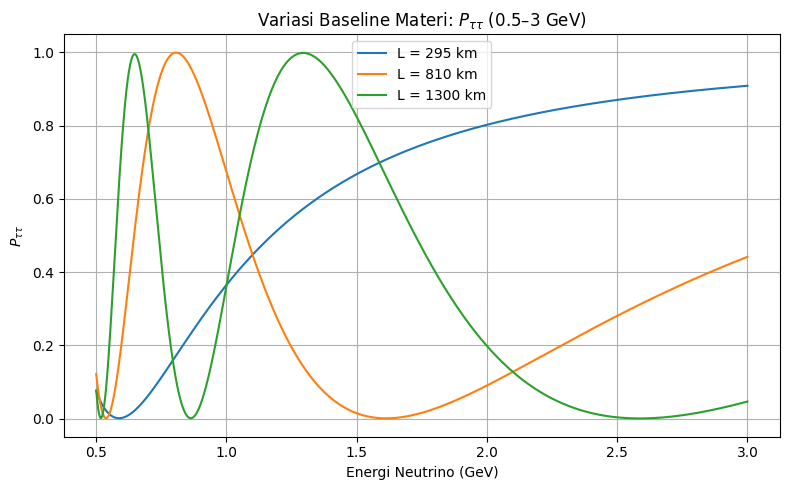

In [39]:
plot_9_baseline_variation(
    baseline_results=baseline_low_mat,
    mode_label="Materi",
    energy_label="0.5–3 GeV"
)

## Densitas ($\rho$)

In [40]:
rho_values = [3, 5, 10]

rho_full_results = probabilities_vs_energy_for_rho(
    E_values_GeV=E_full,
    rho_values=rho_values,
    L_value=1300
)

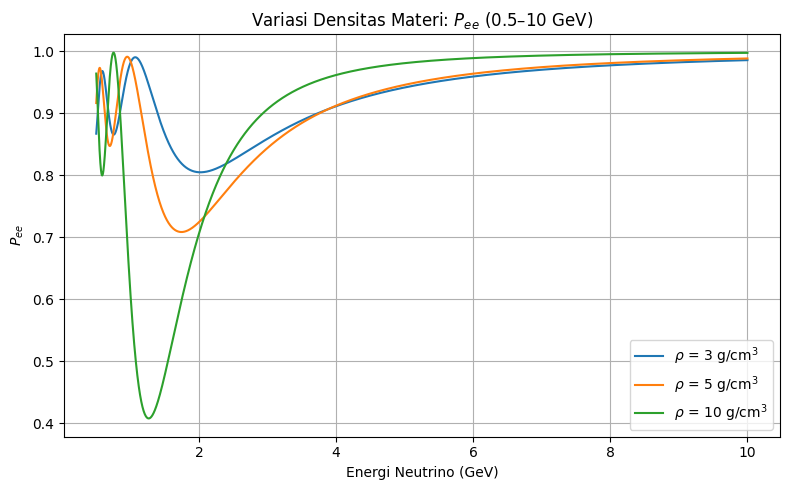

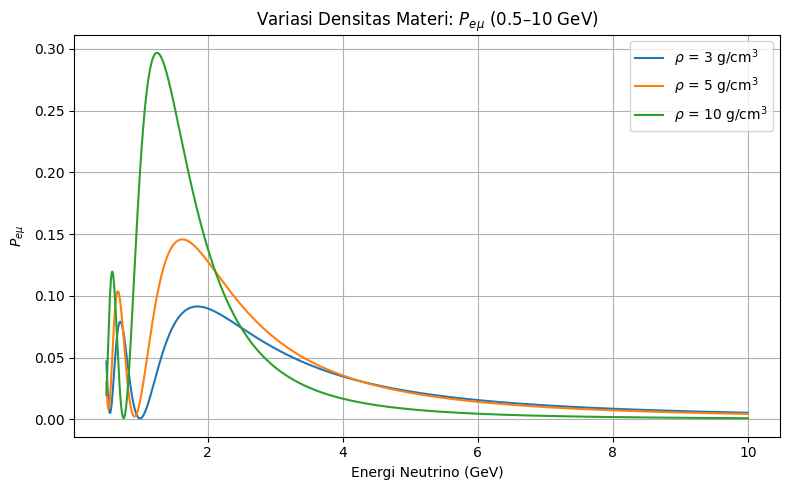

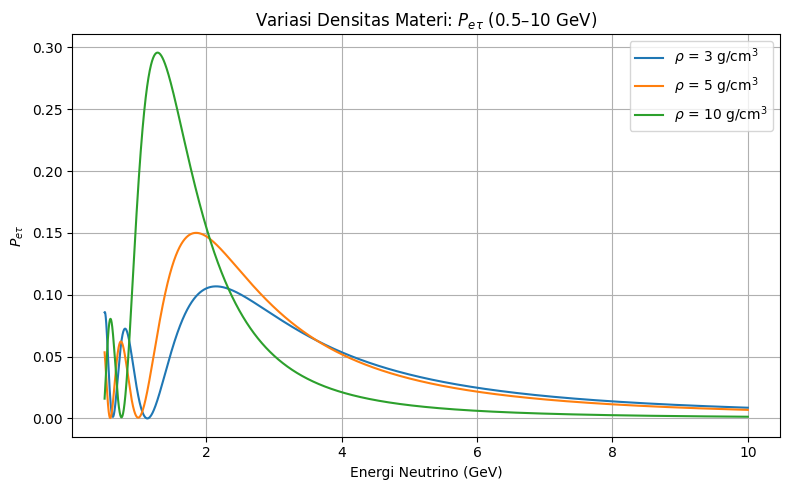

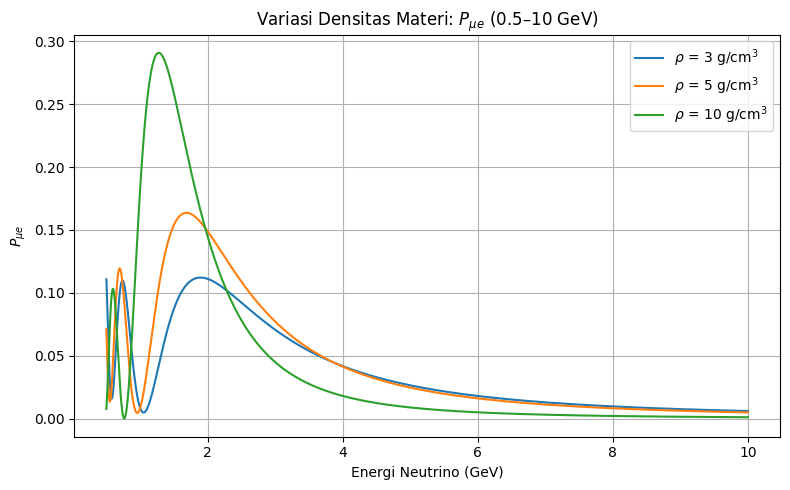

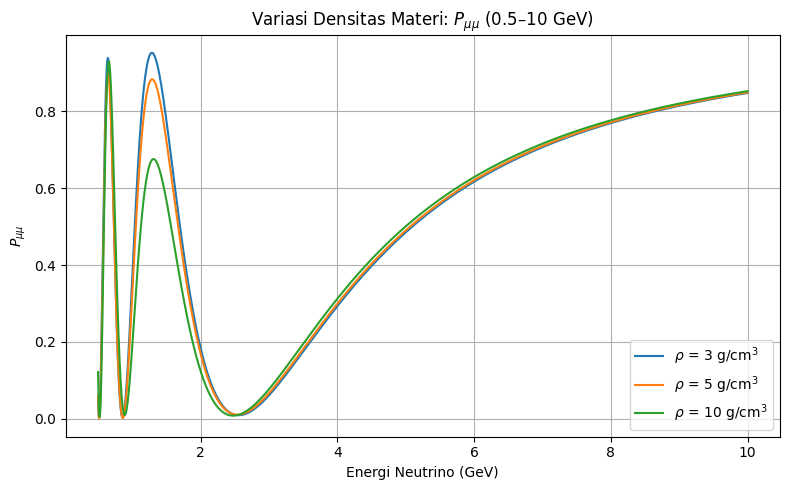

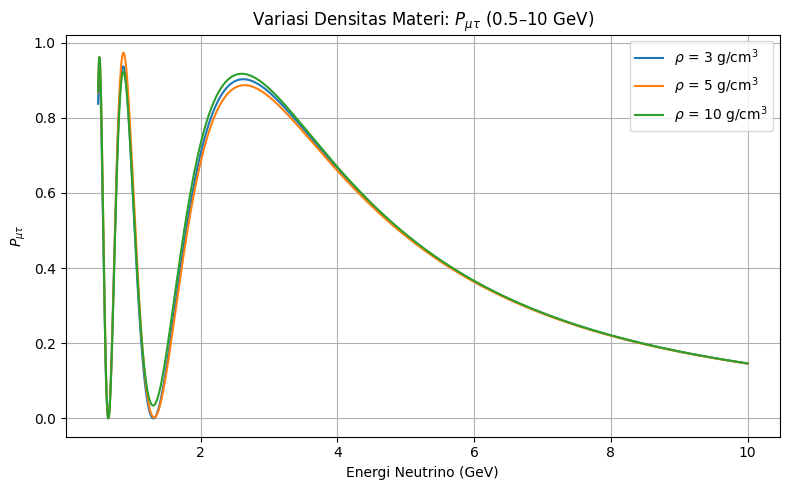

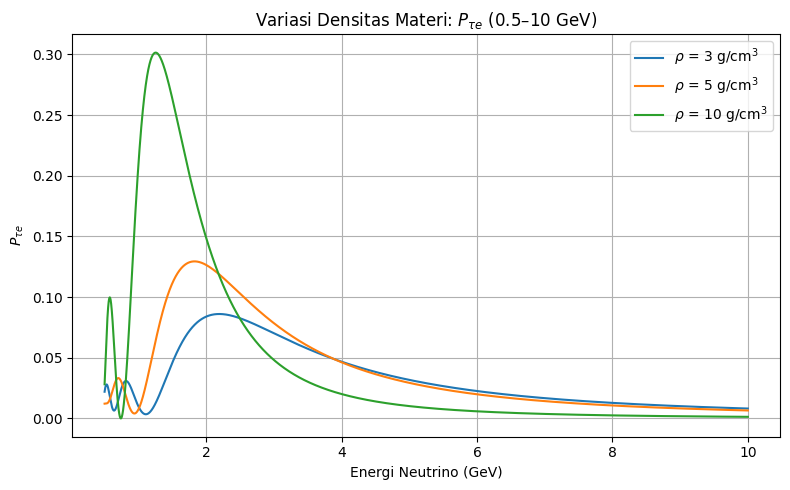

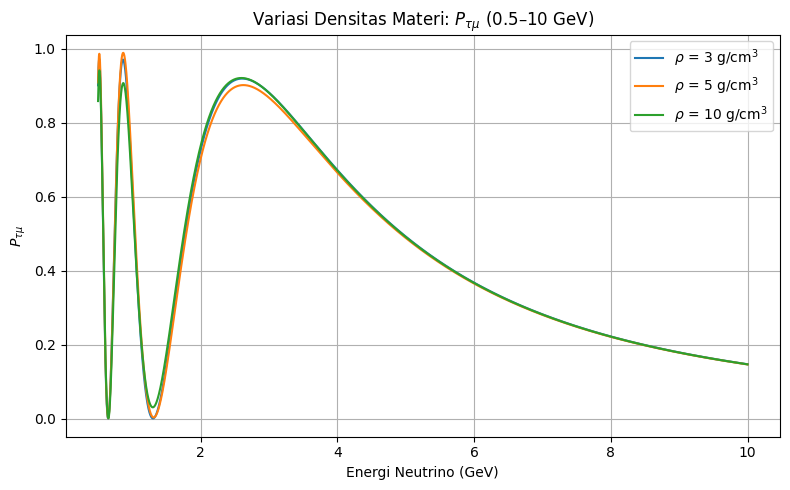

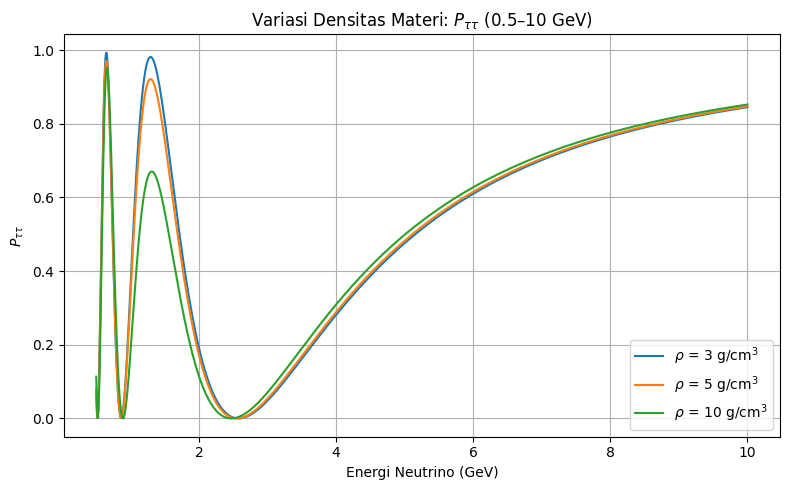

In [41]:
plot_9_rho_variation(
    rho_results=rho_full_results,
    energy_label="0.5–10 GeV"
)

## Tabel puncak dan lembah

In [42]:
summary_peak_valley_rho = summarize_peaks_valleys_rho(
    rho_results=rho_full_results
)

display(summary_peak_valley_rho)

,rho,Probabilitas,Jenis,Urutan,E_GeV,P
0,3,P_e_e,Puncak,1,0.589309,0.968258
1,3,P_e_e,Lembah,1,0.754625,0.865668
2,3,P_e_e,Puncak,2,1.069107,0.990495
3,3,P_e_e,Lembah,2,2.020152,0.804945
4,3,P_e_mu,Lembah,1,0.553205,0.005218
...,...,...,...,...,...,...
111,10,P_tau_tau,Lembah,1,0.522802,0.000850
112,10,P_tau_tau,Puncak,1,0.656766,0.952149
113,10,P_tau_tau,Lembah,2,0.890489,0.000038
114,10,P_tau_tau,Puncak,2,1.309481,0.670466


In [43]:
print(summary_peak_valley_rho.columns.tolist())

['rho', 'Probabilitas', 'Jenis', 'Urutan', 'E_GeV', 'P']


In [44]:
nama_file_rho = "ringkasan_puncak_lembah_densitas.xlsx"

summary_peak_valley_rho.to_excel(
    nama_file_rho,
    sheet_name="Semua Data",
    index=False
)

print(f"File berhasil dibuat: {nama_file_rho}")

File berhasil dibuat: ringkasan_puncak_lembah_densitas.xlsx


In [45]:
from google.colab import files

files.download(nama_file_rho)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Densitas - Energi Rendah

In [46]:
rho_low_results = probabilities_vs_energy_for_rho(
    E_values_GeV=E_low,
    rho_values=rho_values,
    L_value=1300
)

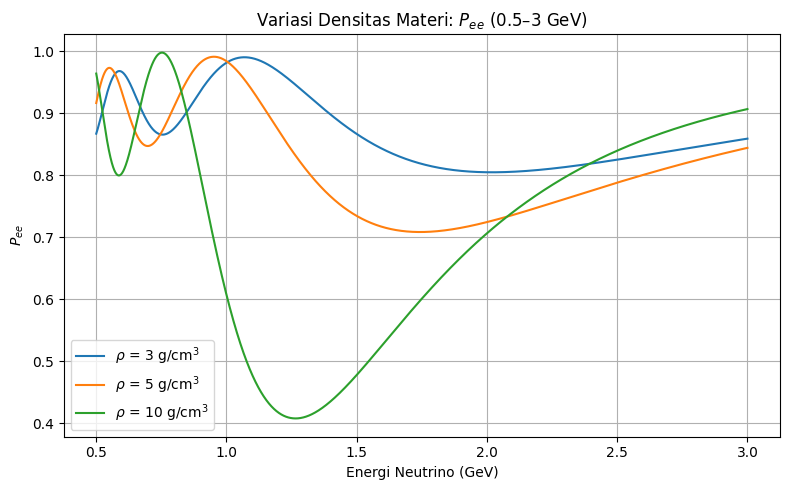

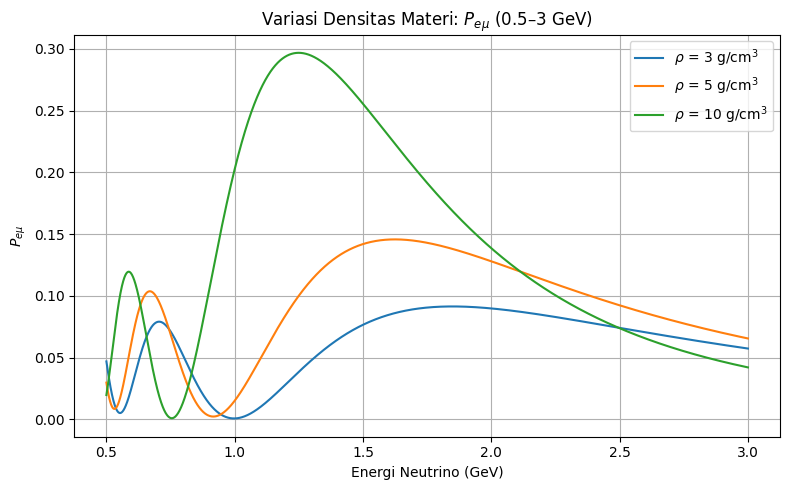

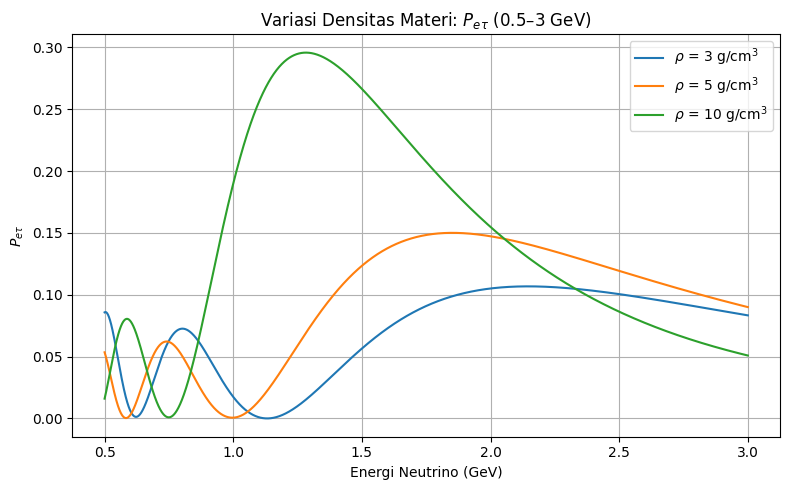

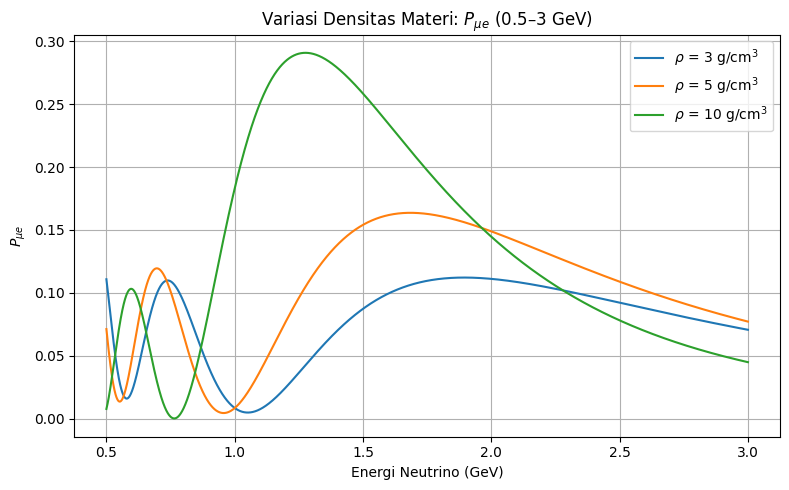

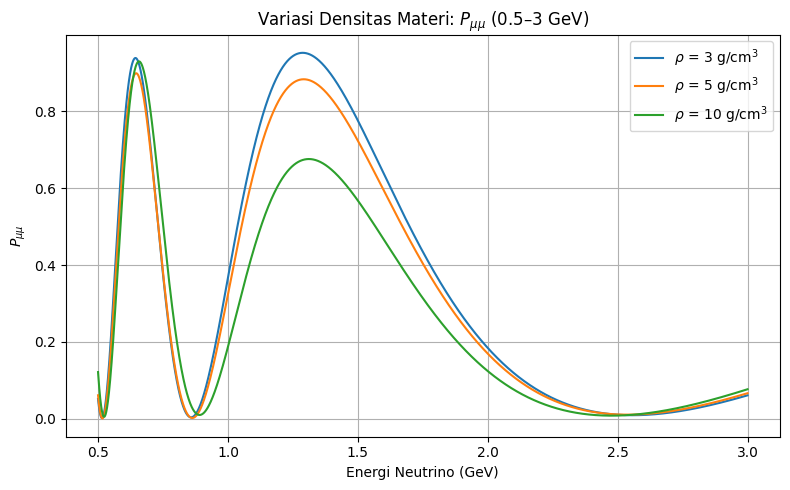

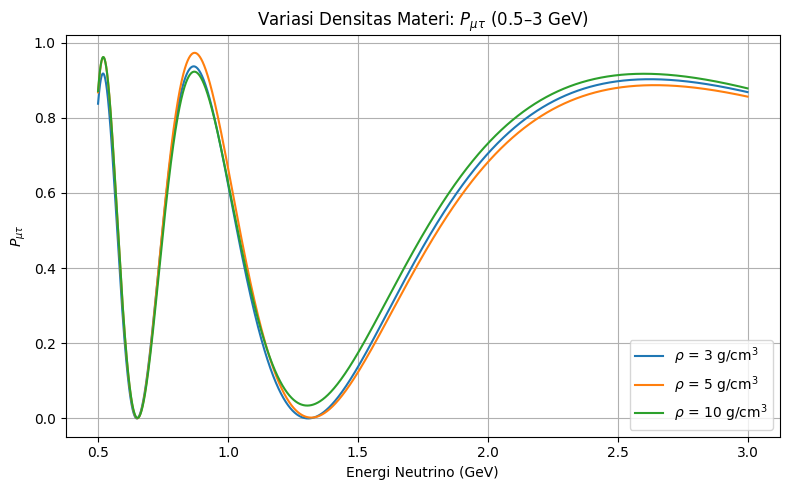

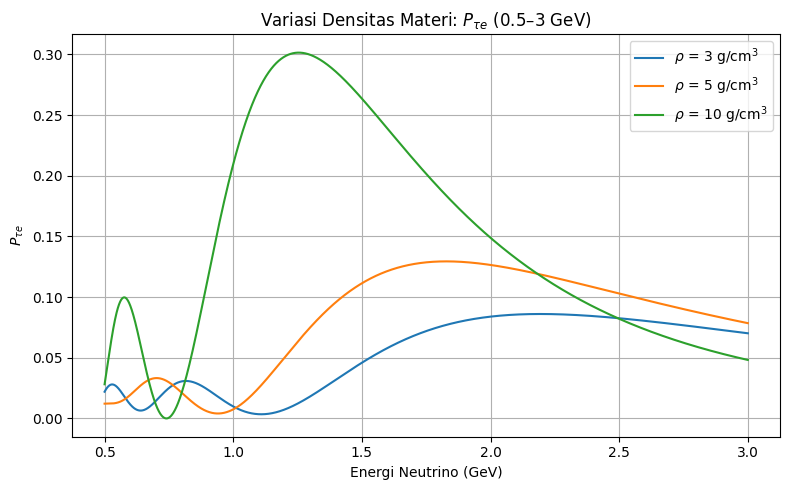

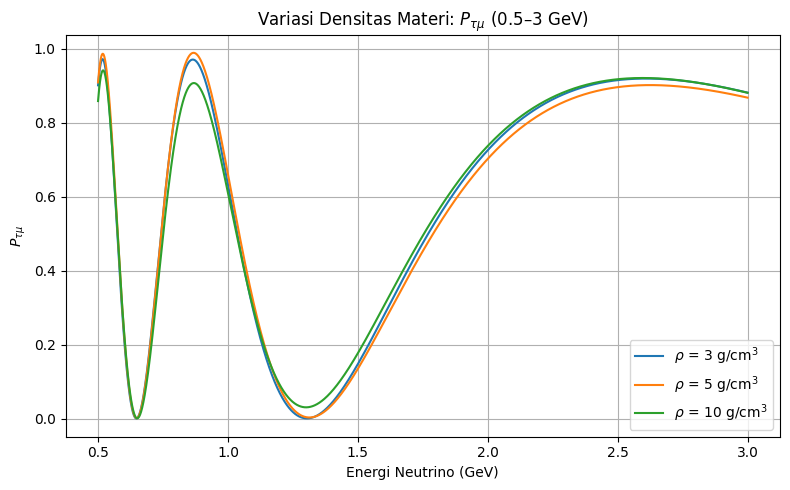

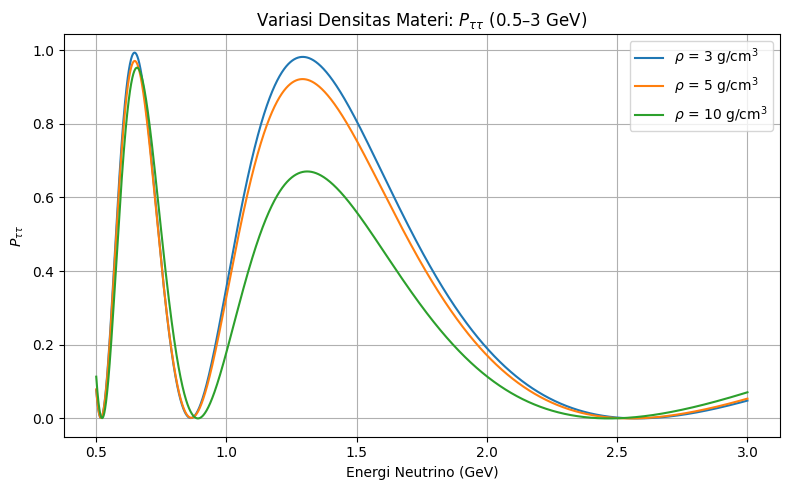

In [47]:
plot_9_rho_variation(
    rho_results=rho_low_results,
    energy_label="0.5–3 GeV"
)

In [48]:
summary_peak_valley_full.to_csv(
    "summary_peak_valley_full_energy.csv",
    index=False
)

summary_peak_valley_baseline.to_csv(
    "summary_peak_valley_baseline.csv",
    index=False
)

summary_peak_valley_rho.to_csv(
    "summary_peak_valley_rho.csv",
    index=False
)

print("Semua tabel peak dan valley berhasil disimpan.")

Semua tabel peak dan valley berhasil disimpan.
